In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import glob
import time
import gc
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, multilabel_confusion_matrix
from timeit import default_timer as timer
import re
from collections import defaultdict
import random


In [2]:
#set TORCH_HOME=E:\MS Thesis\codes\DSTCT-master\code\weights
#os.environ['TORCH_HOME'] = r'E:\New_Project\CoronaryDominanceDataset\MultiTaskingLearning\weights'
os.environ['TORCH_HOME'] = r'E:\MS Thesis\codes\DSTCT-master\code\weights'

# MODEL

In [5]:
class OptimizedTemporalMultiTaskStudent(nn.Module):
    """Optimized model with better memory management."""
    
    def __init__(self, backbone, backbone_type, input_channels=1,
                 num_classes_occlusion=2, num_classes_frame_quality=2,
                 num_classes_dominance=2, hidden_dim=256,
                 sequential_model_type='lstm', sequential_hidden_dim=256,
                 num_sequential_layers=1, bidirectional=False,
                 num_heads_transformer=4, num_transformer_layers=2):
        super().__init__()
        
        self.backbone_type = backbone_type.lower()
        self.backbone = backbone
        self.input_channels = input_channels
        self.hidden_dim = hidden_dim
        self.sequential_model_type = sequential_model_type.lower()
        self.sequential_hidden_dim = sequential_hidden_dim
        self.num_sequential_layers = num_sequential_layers
        self.bidirectional = bidirectional
        self.num_classes_occlusion = num_classes_occlusion
        self.num_classes_frame_quality = num_classes_frame_quality
        self.num_classes_dominance = num_classes_dominance
        
        # Modify backbone for input channels
        self._modify_first_conv_layer()
        
        # Setup feature extractor
        self._setup_feature_extractor()
        
        # Shared components
        self.spatial_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.3)
        
        # Sequential model for occlusion
        self._setup_sequential_model()
        
        # Task heads with optimized architecture
        self._setup_task_heads()
        
        # Enable mixed precision training
        #self.backbone.half() if torch.cuda.is_available() else None
    
    def _setup_feature_extractor(self):
        """Setup optimized feature extractor."""
        if hasattr(self.backbone, 'features'):
            self.extractor = self.backbone.features
            if "densenet" in self.backbone_type:
                self.feature_dim = self.backbone.classifier.in_features
            elif "efficientnet" in self.backbone_type or "mobilenet" in self.backbone_type:
                # Get feature dimension efficiently
                with torch.no_grad():
                    dummy = torch.randn(1, self.input_channels, 224, 224)
                    features = self.extractor(dummy)
                    self.feature_dim = features.shape[1]
            else:
                raise ValueError(f"Unsupported backbone.features type: {self.backbone_type}")
        elif "resnet" in self.backbone_type:
            self.extractor = nn.Sequential(*list(self.backbone.children())[:-2])
            self.feature_dim = self.backbone.fc.in_features
        else:
            raise ValueError(f"Unsupported backbone type: {self.backbone_type}")
    
    def _setup_sequential_model(self):
        """Setup optimized sequential model."""
        if self.sequential_model_type == 'lstm':
            self.temporal_model = nn.LSTM(
                input_size=self.feature_dim,
                hidden_size=self.sequential_hidden_dim,
                num_layers=self.num_sequential_layers,
                batch_first=True,
                bidirectional=self.bidirectional,
                dropout=0.2 if self.num_sequential_layers > 1 else 0
            )
        elif self.sequential_model_type == 'gru':
            self.temporal_model = nn.GRU(
                input_size=self.feature_dim,
                hidden_size=self.sequential_hidden_dim,
                num_layers=self.num_sequential_layers,
                batch_first=True,
                bidirectional=self.bidirectional,
                dropout=0.2 if self.num_sequential_layers > 1 else 0
            )
        else:
            raise ValueError(f"Unsupported sequential model: {self.sequential_model_type}")
        
        self.temporal_feature_dim = self.sequential_hidden_dim * (2 if self.bidirectional else 1)
    
    def _setup_task_heads(self):
        """Setup optimized task heads."""
        # Occlusion head
        self.occlusion_head = nn.Sequential(
            nn.Linear(self.temporal_feature_dim, self.hidden_dim // 2),
            nn.ReLU(inplace=True),
            self.dropout,
            nn.Linear(self.hidden_dim // 2, self.num_classes_occlusion)
        )
        
        # Frame quality head
        self.frame_quality_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(self.feature_dim, self.hidden_dim // 2),
            nn.ReLU(inplace=True),
            self.dropout,
            nn.Linear(self.hidden_dim // 2, self.num_classes_frame_quality)
        )
        
        # Dominance head
        self.dominance_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(self.feature_dim, self.hidden_dim // 2),
            nn.ReLU(inplace=True),
            self.dropout,
            nn.Linear(self.hidden_dim // 2, self.num_classes_dominance)
        )
    
    def forward(self, images_dict):
        outputs = {}
        
        # Process occlusion images (temporal)
        if 'occlusion_images' in images_dict and images_dict['occlusion_images'].nelement() > 0:
            occlusion_clips = images_dict['occlusion_images']
            batch_size, seq_length, C, H, W = occlusion_clips.shape
            
            # Reshape for batch processing
            occlusion_flat = occlusion_clips.view(batch_size * seq_length, C, H, W)
            
            # Extract features efficiently
            with torch.cuda.amp.autocast():
                features = self.extractor(occlusion_flat)
                features = self.spatial_pooling(features).flatten(1)
            
            # Reshape back for temporal processing
            features = features.view(batch_size, seq_length, -1)
            
            # Temporal modeling
            temporal_out, _ = self.temporal_model(features)
            
            # Classification (using last timestep)
            occlusion_logits = self.occlusion_head(temporal_out[:, -1, :])
            outputs['occlusion'] = occlusion_logits.unsqueeze(1)
        
        # Process single frame tasks
        for task, head in [('frame_quality', self.frame_quality_head), ('dominance', self.dominance_head)]:
            input_key = f'{task}_images'
            if input_key in images_dict and images_dict[input_key].nelement() > 0:
                with torch.cuda.amp.autocast():
                    features = self.extractor(images_dict[input_key])
                    logits = head(features)
                outputs[task] = logits.unsqueeze(1)
        
        return outputs
    
    def _modify_first_conv_layer(self):
        """Modify first conv layer for grayscale input."""
        if self.input_channels == 1:
            if "resnet" in self.backbone_type:
                old_conv = self.backbone.conv1
                self.backbone.conv1 = nn.Conv2d(
                    1, old_conv.out_channels, old_conv.kernel_size,
                    old_conv.stride, old_conv.padding, bias=False
                )
                # Copy weights (average RGB channels)
                with torch.no_grad():
                    self.backbone.conv1.weight = nn.Parameter(
                        old_conv.weight.mean(dim=1, keepdim=True)
                    )

            elif "densenet" in self.backbone_type:
                old_conv = self.backbone.features.conv0
                self.backbone.features.conv0 = nn.Conv2d(
                    1, old_conv.out_channels, old_conv.kernel_size,
                    old_conv.stride, old_conv.padding, bias=False
                )
                # Copy weights (average RGB channels)
                with torch.no_grad():
                    self.backbone.features.conv0.weight = nn.Parameter(
                        old_conv.weight.mean(dim=1, keepdim=True)
                    )
            elif "efficientnet" in self.backbone_type or "mobilenet" in self.backbone_type:
                old_conv = self.backbone.features[0][0]
                self.backbone.features[0][0] = nn.Conv2d(
                    1, old_conv.out_channels, old_conv.kernel_size,
                    old_conv.stride, old_conv.padding, bias=False
                )
                # Copy weights (average RGB channels)
                with torch.no_grad():
                    self.backbone.features[0][0].weight = nn.Parameter(
                        old_conv.weight.mean(dim=1, keepdim=True)
                    )
    def freeze_backbone(self):
        """Freezes all parameters in the backbone."""
        for param in self.backbone.parameters():
            param.requires_grad = False
        print("Backbone parameters set to frozen (requires_grad=False).")


    def set_head_trainability(self, task_name, requires_grad, verbose=True):
        """
        Sets requires_grad for all parameters in a specific task head (occlusion, frame_quality, dominance).
        Args:
            task_name (str): 'occlusion', 'frame_quality', or 'dominance'.
            requires_grad (bool): True to make parameters trainable, False to freeze.
            verbose (bool): Whether to print status messages.
        """
        if task_name == 'occlusion':
            for param in self.occlusion_temporal_model.parameters():
                param.requires_grad = requires_grad
            if self.sequential_model_type == 'transformer' and hasattr(self, 'transformer_projection'):
                for param in self.transformer_projection.parameters():
                    param.requires_grad = requires_grad
            for param in self.occlusion_head.parameters():
                param.requires_grad = requires_grad
            if verbose:
                status = "TRAINABLE" if requires_grad else "FROZEN"
                print(f"Parameters for '{task_name}' head (Temporal Model + FC) set to: {status}")
            return
        else: # frame_quality or dominance
            head = getattr(self, f"{task_name}_head", None)
            if head is None:
                raise ValueError(f"Unknown task head: {task_name}. Must be 'occlusion', 'frame_quality', or 'dominance'.")
            for param in head.parameters():
                param.requires_grad = requires_grad
            if verbose:
                status = "TRAINABLE" if requires_grad else "FROZEN"
                print(f"Parameters for '{task_name}' head set to: {status}")

    def set_backbone_trainability(self, num_unfreeze_layers=0, verbose=True):
        """
        Sets the trainability of the backbone layers for fine-tuning.
        First, ensures all backbone layers are frozen, then unfreezes the last `num_unfreeze_layers`.

        Args:
            num_unfreeze_layers (int): The number of modules/layers from the end of the backbone's
                                        feature extractor to unfreeze.
                                        If 0, the entire backbone remains frozen.
                                        If -1, all backbone layers are unfrozen.
            verbose (bool): If True, prints messages about which layers are unfrozen.
        """
        # Ensure all backbone layers are frozen first, to reset state
        self.freeze_backbone() # This will print its own message

        # Get all relevant modules/layers of the backbone for granular control
        # Note: This logic might need slight adjustments based on specific torchvision model versions.
        if "densenet" in self.backbone_type and hasattr(self.backbone, 'features'):
            backbone_modules = list(self.backbone.features.children())
        elif "resnet" in self.backbone_type:
            # Exclude the final avgpool and fc layer, focus on conv blocks
            backbone_modules = list(self.backbone.children())[:-2]
        elif "efficientnet" in self.backbone_type or "mobilenet" in self.backbone_type:
            if hasattr(self.backbone, 'features'):
                backbone_modules = list(self.backbone.features.children())
            elif hasattr(self.backbone, 'blocks'): # For some newer EfficientNet implementations
                backbone_modules = list(self.backbone.blocks.children())
            else:
                if verbose: print(f"Warning: Could not determine specific module list for {self.backbone_type}, using top-level children.")
                backbone_modules = list(self.backbone.children())
        elif "inception" in self.backbone_type:
            # For Inception, self.extractor is already a Sequential of its main feature blocks.
            backbone_modules = list(self.extractor.children())
        else:
            if verbose:
                print(f"Warning: Backbone type '{self.backbone_type}' not specifically handled for granular unfreezing. Attempting generic unfreezing.")
            backbone_modules = list(self.backbone.children()) # Fallback for other models

        if num_unfreeze_layers == -1:
            # Unfreeze all layers
            for param in self.backbone.parameters():
                param.requires_grad = True
            if verbose:
                print("All backbone parameters are unfrozen.")
            return

        if num_unfreeze_layers > 0:
            if num_unfreeze_layers > len(backbone_modules):
                num_unfreeze_layers = len(backbone_modules)
                if verbose:
                    print(f"Requested to unfreeze {num_unfreeze_layers} layers, but backbone has only {len(backbone_modules)} relevant modules. Unfreezing all {len(backbone_modules)}.")

            # Unfreeze the last `num_unfreeze_layers` modules
            for i, module in enumerate(backbone_modules[::-1][:num_unfreeze_layers]): # Iterate from the end
                for param in module.parameters():
                    param.requires_grad = True
                if verbose:
                    # Print original index of the module for clarity
                    original_idx = len(backbone_modules) - 1 - i
                    print(f"Unfrozen module: {original_idx} - {module.__class__.__name__}")
            if verbose:
                print(f"Successfully unfrozen the last {num_unfreeze_layers} backbone modules.")
        else:
            if verbose:
                print("No additional backbone layers unfrozen (num_unfreeze_layers was 0). Backbone remains entirely frozen.")

In [6]:
class VideoClassifierTeacher(nn.Module):
    """
    A flexible video classification model that allows for different backbones and
    sequential models, and handles grayscale input.
    """
    def __init__(self, num_classes, backbone_name='resnet18', input_channels=1,
                 sequential_model_type='lstm', hidden_dim=512,
                 num_sequential_layers=2, bidirectional=True, dropout=0.5,
                 n_transformer_heads=8, n_transformer_layers=4):
        super().__init__()

        self.backbone_name = backbone_name
        self.sequential_model_type = sequential_model_type.lower()

        # --- 1. Get CNN Backbone and Feature Dimension ---
        self.feature_extractor, self.feature_dim = self._get_backbone(backbone_name, input_channels)

        # --- 2. Define Sequential Model ---
        if self.sequential_model_type == 'lstm' or self.sequential_model_type == 'gru':
            if self.sequential_model_type == 'lstm':
                self.sequential_model = nn.LSTM(
                    input_size=self.feature_dim, hidden_size=hidden_dim,
                    num_layers=num_sequential_layers, batch_first=True,
                    dropout=dropout if num_sequential_layers > 1 else 0,
                    bidirectional=bidirectional
                )
            else: # GRU
                self.sequential_model = nn.GRU(
                    input_size=self.feature_dim, hidden_size=hidden_dim,
                    num_layers=num_sequential_layers, batch_first=True,
                    dropout=dropout if num_sequential_layers > 1 else 0,
                    bidirectional=bidirectional
                )
            temporal_feature_dim = hidden_dim * 2 if bidirectional else hidden_dim
        
        elif self.sequential_model_type == 'transformer':
            self.pos_encoder = nn.Parameter(torch.zeros(1, 100, self.feature_dim)) # Max 100 frames
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=self.feature_dim, nhead=n_transformer_heads,
                dim_feedforward=hidden_dim, dropout=dropout, batch_first=True
            )
            self.sequential_model = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)
            temporal_feature_dim = self.feature_dim
        
        else:
            raise ValueError(f"Unsupported sequential model type: {sequential_model_type}")

        # --- 3. Define Classifier Head ---
        self.classifier = nn.Sequential(
            nn.Linear(temporal_feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def _get_backbone(self, name, input_channels):
        """Loads a pre-trained backbone and modifies it for grayscale if needed."""
        print(f"Loading backbone: {name}")
        # Load pre-trained model
        if name == 'resnet18':
            model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            feature_dim = model.fc.in_features
            if input_channels == 1:
                model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            extractor = nn.Sequential(*list(model.children())[:-1])
        elif name == 'densenet121':
            model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
            feature_dim = model.classifier.in_features
            if input_channels == 1:
                model.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            extractor = model.features
        elif name == 'efficientnet_b0':
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
            feature_dim = model.classifier[1].in_features
            if input_channels == 1:
                model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
            extractor = model.features
        elif name == 'mobilenet_v2':
            model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
            feature_dim = model.classifier[1].in_features
            if input_channels == 1:
                model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
            extractor = model.features
        elif name == 'vit_b_16':
            model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
            feature_dim = model.heads.head.in_features
            if input_channels == 1:
                 # Modify the patch embedding layer
                old_conv = model.conv_proj
                model.conv_proj = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size, stride=old_conv.stride)
            # For ViT, the "extractor" is the whole model except the final classification head
            extractor = nn.Sequential(*list(model.children())[:-1])
        else:
            raise ValueError(f"Unsupported backbone: {name}")
        
        print(f"Backbone '{name}' loaded. Feature dimension: {feature_dim}. Input channels: {input_channels}.")
        return extractor, feature_dim

    def forward(self, x):
        batch_size, seq_length, c, h, w = x.shape
        x_reshaped = x.view(batch_size * seq_length, c, h, w)
        
        features = self.feature_extractor(x_reshaped)
        
        if self.backbone_name == 'vit_b_16':
            # ViT's output from the sequential block is already (N*S, D)
            features = features.view(batch_size, seq_length, -1)
        else:
            #if "densenet" in self.backbone_name:
            features = F.adaptive_avg_pool2d(features, (1, 1))
            # Other CNNs need flattening
            features = features.view(batch_size, seq_length, self.feature_dim)

        # --- Temporal Modeling ---
        if self.sequential_model_type == 'transformer':
            # Add positional encoding
            features += self.pos_encoder[:, :seq_length, :]
            temporal_out = self.sequential_model(features)
            # Use the output of the [CLS] token equivalent, which is the mean of all frame features
            temporal_out = temporal_out.mean(dim=1)
        else: # LSTM or GRU
            temporal_out, _ = self.sequential_model(features)
            # We take the output of the last time step for classification
            temporal_out = temporal_out[:, -1, :]
        
        logits = self.classifier(temporal_out)
        return logits

In [7]:
import os
print(os.getcwd())
os.chdir(r"E:\Morshedul\CoronarDominance\codes")
print(os.getcwd())

E:\Morshedul\CoronarDominance
E:\Morshedul\CoronarDominance\codes


In [8]:
from models import *
def load_teacher_model(model_path, backbone_type, input_channels, num_classes=2, device='cpu'):
    model = None
    backbone_type = backbone_type.lower()

    # Instantiate the correct backbone
    if backbone_type == "resnet":
        model = models.resnet18(weights="DEFAULT")
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif backbone_type == "densenet":
        #model = models.densenet121(weights="DEFAULT")
        model = models.densenet121(weights='DEFAULT', memory_efficient=True)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif backbone_type == "efficientnet":
        model = models.efficientnet_b0(weights="DEFAULT")
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif backbone_type == "mobilenet":
        model = models.mobilenet_v2(weights="DEFAULT")
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif backbone_type == "inception":
        model = models.inception_v3(weights="DEFAULT", aux_logits=False)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        raise ValueError(f"Unsupported backbone type for teacher: {backbone_type}")

    # Modify first conv layer for grayscale if needed
    if input_channels == 1:
        if backbone_type == "resnet":
            old_conv = model.conv1
            model.conv1 = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size, 
                                  stride=old_conv.stride, padding=old_conv.padding, bias=False)
            # Copy weights efficiently
            with torch.no_grad():
                model.conv1.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
        elif backbone_type == "densenet":
            old_conv = model.features.conv0
            model.features.conv0 = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                                           stride=old_conv.stride, padding=old_conv.padding, bias=False)
            with torch.no_grad():
                model.features.conv0.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
        elif backbone_type == "efficientnet" or backbone_type == "mobilenet":
            old_conv = model.features[0][0]
            model.features[0][0] = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                                           stride=old_conv.stride, padding=old_conv.padding, bias=False)
            with torch.no_grad():
                model.features[0][0].weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
        elif backbone_type == "inception":
            old_conv = model.Conv2d_1a_3x3.conv
            model.Conv2d_1a_3x3.conv = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size, stride=old_conv.stride, padding=old_conv.padding, bias=old_conv.bias)

    model.to(device)

    try:
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)
        if isinstance(checkpoint, dict) and 'model' in checkpoint:
            model = checkpoint['model']
        elif isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
        
        model.to(device)
    except Exception as e:
        print(f"Error loading teacher model from {model_path}: {e}")
        raise

    model.eval() # Set to evaluation mode
    for param in model.parameters():
        param.requires_grad = False # Freeze teacher

    print(f"Loaded and froze teacher model ({backbone_type}) from: {model_path}")
    return model



# DATALOADER

In [9]:
class OptimizedTemporalMTDDataset(Dataset):
    """Heavily optimized dataset with caching and smart indexing."""
    
    def __init__(self, root_dir, split_type, view_type, clip_length, transform=None, fold_num=1):
        self.root_dir = root_dir
        self.split_type = split_type
        self.view_type = view_type
        self.clip_length = clip_length
        self.transform = transform
        self.fold_num = fold_num
        self.IGNORE_LABEL_VALUE = -1
        
        # Label mappings
        self.occlusion_label_map = {'nonoccluded': 0, 'occluded': 1}
        self.frame_quality_label_map = {'noninformative': 0, 'informative': 1}
        self.dominance_label_map = {'rightdom': 0, 'leftdom': 1}
        
        # Optimized data structures
        self.samples = []  # Main sample list
        self.video_frame_cache = {}  # Cache for video frames
        self.precomputed_clips = []  # Pre-computed clip indices
        
        self._load_and_optimize_data()
        self._balance_dataset()
        
    def _load_and_optimize_data(self):
        """Load data with optimized indexing and pre-computation."""
        print(f"--- Optimized loading {self.split_type} data for {self.view_type} view ---")
        
        # Load all tasks simultaneously
        task_data = {
            'occlusion': self._load_task_data('occlusion', 'occlusion', self.occlusion_label_map, f'occlusion/DATA_RCA'),
            'frame_quality': self._load_task_data('framequality', 'framequality', self.frame_quality_label_map, f'framequality/DATA_{self.view_type}'),
            'dominance': self._load_task_data('dom', 'dominance', self.dominance_label_map, f'dominance/DATA_{self.view_type}')
        }
        
        # Process occlusion clips if RCA view
        if self.view_type == 'RCA' and task_data['occlusion']:
            self._process_occlusion_clips(task_data['occlusion'])
        
        # Create unified sample list
        max_samples = max(
            len(self.precomputed_clips) if self.view_type == 'RCA' else 0,
            len(task_data['frame_quality']) if task_data['frame_quality'] else 0,
            len(task_data['dominance']) if task_data['dominance'] else 0
        )
        
        for i in range(max_samples):
            sample = {
                'occlusion_clip': self.precomputed_clips[i % len(self.precomputed_clips)] if self.precomputed_clips else None,
                'frame_quality': task_data['frame_quality'][i % len(task_data['frame_quality'])] if task_data['frame_quality'] else None,
                'dominance': task_data['dominance'][i % len(task_data['dominance'])] if task_data['dominance'] else None
            }
            self.samples.append(sample)
            
        print(f"Created {len(self.samples)} optimized samples")
    
    def _load_task_data(self, csv_prefix, task_name, label_map, data_path):
        """Load task data efficiently."""
        csv_path = os.path.join(self.root_dir, data_path, 'labels', f'{csv_prefix}_{self.split_type}_labels_fold_{self.fold_num}.csv')
        
        if not os.path.exists(csv_path):
            return []
            
        df = pd.read_csv(csv_path)
        task_data = []
        
        for _, row in df.iterrows():
            filename = str(row['filename'])
            label_str = str(row['label']).strip().lower()
            label = label_map.get(label_str)
            
            if label is None:
                continue
                
            path = os.path.join(self.root_dir, data_path, label_str, filename)
            if os.path.exists(path):
                task_data.append((path, label, filename))
                
        print(f"Loaded {len(task_data)} {task_name} samples")
        return task_data
    
    def _process_occlusion_clips(self, occlusion_data):
        """Pre-process occlusion clips for efficiency."""
        video_frames = defaultdict(list)
        
        # Group frames by video
        for path, label, filename in occlusion_data:
            match = re.match(r'(.+)_frame_(\d+)\.png', filename)
            if match:
                video_id = match.group(1)
                frame_idx = int(match.group(2))
                video_frames[video_id].append((frame_idx, path, label))
        
        # Create clips
        for video_id, frames in video_frames.items():
            frames.sort(key=lambda x: x[0])  # Sort by frame index
            
            if len(frames) >= self.clip_length:
                # Create multiple clips per video with stride
                stride = max(1, self.clip_length // 4)  # 75% overlap
                for i in range(0, len(frames) - self.clip_length + 1, stride):
                    clip_frames = frames[i:i + self.clip_length]
                    self.precomputed_clips.append({
                        'video_id': video_id,
                        'frames': clip_frames,
                        'label': clip_frames[-1][2]  # Use last frame's label
                    })
        
        print(f"Created {len(self.precomputed_clips)} occlusion clips from {len(video_frames)} videos")
    
    def _balance_dataset(self):
        """Optional: Balance dataset if needed."""
        # You can implement dataset balancing here if required
        pass
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Get occlusion clip
        occ_clip, occ_label = self._get_occlusion_clip(sample['occlusion_clip'])
        
        # Get single frame tasks
        fq_image, fq_label = self._get_single_frame_task(sample['frame_quality'])
        dom_image, dom_label = self._get_single_frame_task(sample['dominance'])
        
        return {
            'inputs': {
                'occlusion_images': occ_clip,
                'frame_quality_images': fq_image,
                'dominance_images': dom_image
            },
            'labels': {
                'occlusion': occ_label,
                'frame_quality': fq_label,
                'dominance': dom_label
            }
        }
    
    def _get_occlusion_clip(self, clip_data):
        """Get occlusion clip with caching."""
        if clip_data is None:
            return torch.zeros(0, self.clip_length, 1, 512, 512), torch.tensor(self.IGNORE_LABEL_VALUE, dtype=torch.long)
        
        # Use caching for frequently accessed clips
        clip_key = clip_data['video_id']
        
        try:
            # Load images efficiently
            clip_frames = []
            for _, path, _ in clip_data['frames']:
                # Use PIL with optimizations
                with Image.open(path) as img:
                    img = img.convert('L')
                    if self.transform:
                        img = self.transform.transform(img)
                    clip_frames.append(img)
            
            clip_tensor = torch.stack(clip_frames)
            label = torch.tensor(clip_data['label'], dtype=torch.long)
            
            return clip_tensor, label
            
        except Exception as e:
            print(f"Error loading occlusion clip: {e}")
            return torch.zeros(0, self.clip_length, 1, 512, 512), torch.tensor(self.IGNORE_LABEL_VALUE, dtype=torch.long)
    
    def _get_single_frame_task(self, task_data):
        """Get single frame task data."""
        if task_data is None:
            return torch.zeros(0, 1, 512, 512), torch.tensor(self.IGNORE_LABEL_VALUE, dtype=torch.long)
        
        try:
            path, label, _ = task_data
            with Image.open(path) as img:
                img = img.convert('L')
                if self.transform:
                    img = self.transform.transform(img)
            
            return img, torch.tensor(label, dtype=torch.long)
            
        except Exception as e:
            print(f"Error loading single frame: {e}")
            return torch.zeros(0, 1, 512, 512), torch.tensor(self.IGNORE_LABEL_VALUE, dtype=torch.long)



In [10]:
class OptimizedClipAndFrameTransform:
    """Optimized transform with minimal overhead."""
    
    def __init__(self, img_size, mean, std):
        self.size = img_size if isinstance(img_size, tuple) else (img_size, img_size)
        self.mean = mean[0] if isinstance(mean, list) else mean
        self.std = std[0] if isinstance(std, list) else std
        
        # Pre-compute transform for efficiency
        self.transform = transforms.Compose([
            transforms.Resize(self.size, antialias=True),
            transforms.ToTensor(),
            transforms.Normalize(mean=[self.mean], std=[self.std])
        ])
    
    def __call__(self, images):
        if isinstance(images, list):
            # Batch process list of images
            return torch.stack([self.transform(img) for img in images])
        else:
            return self.transform(images)

In [11]:
def collate_fn_optimized(batch):
    """Optimized collate function for better batching."""
    inputs = {'occlusion_images': [], 'frame_quality_images': [], 'dominance_images': []}
    labels = {'occlusion': [], 'frame_quality': [], 'dominance': []}
    
    for sample in batch:
        for key in inputs:
            if sample['inputs'][key].nelement() > 0:
                inputs[key].append(sample['inputs'][key])
        
        for key in labels:
            labels[key].append(sample['labels'][key])
    
    # Stack tensors efficiently
    for key in inputs:
        if inputs[key]:
            inputs[key] = torch.stack(inputs[key])
        else:
            inputs[key] = torch.zeros(0)
    
    for key in labels:
        labels[key] = torch.stack(labels[key])
    
    return {'inputs': inputs, 'labels': labels}

# TRAIN

In [12]:
def train_optimized_multi_task_mtd(student_model, teachers, train_dl, val_dl, criterions, optimizer, scheduler,
                                   device, n_epochs, checkpoint_name, mtd_params, view_to_train, categories_map,
                                   gradient_accumulation_steps=1, max_epochs_stop=10, resume_path=None,save_freq=10):
    """Optimized training loop with better performance."""
    
    # Enable optimizations
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    
    scaler = torch.amp.GradScaler('cuda')
    best_val_accuracy = 0.0
    start_epoch, epochs_no_improve, history = 0, 0, []
    
    # Task key mapping
    task_key_map = {'occlusion': 'occ', 'frame_quality': 'fq', 'dominance': 'dom'}


    # Create checkpoint directory structure
    checkpoint_dir = os.path.dirname(checkpoint_name)
    best_model_path = checkpoint_name
    latest_checkpoint_path = os.path.join(checkpoint_dir, 'last_checkpoint.pth')
    # Create periodic checkpoint directory if save_freq > 0
    if save_freq > 0:
        periodic_checkpoint_dir = os.path.join(checkpoint_dir, 'periodic_checkpoints')
        os.makedirs(periodic_checkpoint_dir, exist_ok=True)

    print(f"Checkpoint directory: {checkpoint_dir}")
    print(f"Best model will be saved as: {best_model_path}")
    print(f"Latest checkpoint will be saved as: {latest_checkpoint_path}")
    if save_freq > 0:
        print(f"Periodic checkpoints will be saved every {save_freq} epochs in: {periodic_checkpoint_dir}")

    
    # Resume if needed
    if resume_path and os.path.exists(resume_path):
        print(f"Resuming training from {resume_path}")
        ckpt = torch.load(resume_path, map_location=device)
        student_model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch = ckpt.get('epoch', 0) + 1
        history = ckpt.get('history', [])
        best_val_accuracy = ckpt.get('best_val_accuracy', 0.0)
    
    for epoch in range(start_epoch, n_epochs):
        student_model.train()
        train_loss = 0.0
        train_trackers = {task: {'loss': 0, 'correct': 0, 'total': 0, 'batches': 0} for task in criterions}
        
        # Training loop with optimizations
        progress_bar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{n_epochs}")
        optimizer.zero_grad(set_to_none=True)
        
        for i, data in enumerate(progress_bar):
            inputs = {k: v.to(device, non_blocking=True) for k, v in data['inputs'].items() if v.nelement() > 0}
            labels = {k: v.to(device, non_blocking=True) for k, v in data['labels'].items() if v.nelement() > 0}
            
            if not labels:
                continue
            
            # Forward pass with mixed precision
            with torch.amp.autocast('cuda'):
                student_outputs = student_model(inputs)
                total_loss = torch.tensor(0.0, device=device)
                
                for task, s_logits in student_outputs.items():
                    if task not in labels:
                        continue
                    if task == 'occlusion' and view_to_train != 'RCA':
                        continue
                    
                    # Get logits for loss computation
                    if task == 'occlusion':
                        s_logits_for_loss = s_logits.squeeze(1)
                    else:
                        s_logits_for_loss = s_logits.squeeze(1)
                    
                    # Compute ground truth loss
                    gt_loss = criterions[task](s_logits_for_loss, labels[task])
                    
                    # Apply MTD parameters
                    alpha_key = f'alpha_{task_key_map[task]}'
                    final_loss = (1 - mtd_params[alpha_key]) * gt_loss
                    
                    # Add distillation loss if teacher available
                    if teachers.get(task) and f'{task}_images' in inputs:
                        with torch.no_grad():
                            teacher_logits = teachers[task](inputs[f'{task}_images'])
                            if teacher_logits.dim() > 2:
                                teacher_logits = teacher_logits.squeeze(1)
                        
                        distill_loss = F.kl_div(
                            F.log_softmax(s_logits_for_loss / mtd_params['temp'], dim=1),
                            F.softmax(teacher_logits / mtd_params['temp'], dim=1),
                            reduction='batchmean'
                        ) * (mtd_params['temp'] ** 2)
                        
                        final_loss += mtd_params[alpha_key] * distill_loss
                    
                    total_loss += final_loss
                    
                    # Update trackers
                    train_trackers[task]['loss'] += gt_loss.item()
                    _, preds = torch.max(s_logits_for_loss, 1)
                    train_trackers[task]['correct'] += (preds == labels[task]).sum().item()
                    train_trackers[task]['total'] += labels[task].size(0)
                    train_trackers[task]['batches'] += 1
            
            # Backward pass with gradient accumulation
            scaler.scale(total_loss / gradient_accumulation_steps).backward()
            
            if (i + 1) % gradient_accumulation_steps == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
                
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            
            train_loss += total_loss.item()
            progress_bar.set_postfix(loss=train_loss / (i + 1))
            
            # Memory cleanup every 50 batches
            if (i + 1) % 50 == 0:
                torch.cuda.empty_cache()
        
        # Validation and logging
        avg_train_loss = train_loss / len(train_dl)
        val_results = evaluate_model_optimized(
            student_model, val_dl, criterions, device, view_to_train, -1, categories_map, is_training=True
        )
        
        scheduler.step(val_results['overall_loss'])
        
        # History tracking
        epoch_history = {
            'Epoch': epoch + 1,
            'Train_Loss': avg_train_loss,
            'Val_Loss': val_results['overall_loss'],
            'Val_Avg_Acc': val_results['overall_test_accuracy']
        }
        
        # Print epoch summary
        print(f"\n--- Epoch {epoch+1} Summary ---")
        print(f"Overall -> Train Loss: {avg_train_loss:.4f}, Val Loss: {val_results['overall_loss']:.4f}, Val Avg Acc: {val_results['overall_test_accuracy']:.2f}%")
        
        for task in val_results.keys():
            if isinstance(val_results[task], dict) and 'test_acc' in val_results[task]:
                train_acc = (train_trackers[task]['correct'] / train_trackers[task]['total']) * 100 if train_trackers[task]['total'] > 0 else 0
                train_loss_task = train_trackers[task]['loss'] / train_trackers[task]['batches'] if train_trackers[task]['batches'] > 0 else 0
                
                epoch_history.update({
                    f'Train_{task}_Acc': train_acc,
                    f'Val_{task}_Acc': val_results[task]['test_acc'] * 100,
                    f'Train_{task}_Loss': train_loss_task,
                    f'Val_{task}_Loss': val_results[task]['test_loss']
                })
                
                print(f"  {task.title():<15} -> Train Acc: {train_acc:.2f}%, Val Acc: {val_results[task]['test_acc']*100:.2f}%")
        
        history.append(epoch_history)
        
        # Save best model
        if val_results['overall_test_accuracy'] > best_val_accuracy:
            best_val_accuracy = val_results['overall_test_accuracy']
            epochs_no_improve = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': student_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_accuracy': best_val_accuracy,
                'history': history
            }, f"{checkpoint_name}_best.pth")
            print(f" >> Saved best model with val accuracy: {best_val_accuracy:.2f}%")
        else:
            epochs_no_improve += 1
        # Save periodic checkpoint if enabled
        if save_freq > 0 and (epoch + 1) % save_freq == 0:
            periodic_checkpoint_path = os.path.join(periodic_checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth')
            # Save last checkpoint
            torch.save({
                'epoch': epoch,
                'model_state_dict': student_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_accuracy': best_val_accuracy,
                'history': history
            }, periodic_checkpoint_path)
            print(f"Periodic checkpoint saved: {periodic_checkpoint_path}")
        # Save last checkpoint
        #torch.save({
        #    'epoch': epoch,
        #    'model_state_dict': student_model.state_dict(),
        #    'optimizer_state_dict': optimizer.state_dict(),
        #    'best_val_accuracy': best_val_accuracy,
        #    'history': history
        #}, f"{checkpoint_name}_last.pth")
        
        # Early stopping
        if epochs_no_improve >= max_epochs_stop:
            print(f"Early stopping after {max_epochs_stop} epochs.")
            break
        
        # Memory cleanup
        gc.collect()
        torch.cuda.empty_cache()
    
    return student_model, pd.DataFrame(history)


def evaluate_model_optimized(model, test_dl, criteria, device, view_to_train, ignore_label_value, categories_map, is_training=False):
    """Optimized evaluation function."""
    model.eval()
    active_tasks = ['frame_quality', 'dominance']
    if view_to_train == 'RCA':
        active_tasks.insert(0, 'occlusion')
    
    task_results = {task: {'targets': [], 'preds': [], 'loss': 0, 'batches': 0} for task in active_tasks}
    
    total_time, num_batches = 0, 0
    
    with torch.no_grad():
        for data in tqdm(test_dl, desc=f"Evaluating ({view_to_train})", disable=is_training):
            inputs = {k: v.to(device, non_blocking=True) for k, v in data['inputs'].items() if v.nelement() > 0}
            labels = {k: v.to(device, non_blocking=True) for k, v in data['labels'].items() if v.nelement() > 0}
            
            if not labels:
                continue
            
            num_batches += 1
            start_time = timer()
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
            
            torch.cuda.synchronize()
            total_time += (timer() - start_time)
            
            for task, logits in outputs.items():
                if task not in labels:
                    continue
                if task == 'occlusion' and view_to_train != 'RCA':
                    continue
                
                logits_for_loss = logits.squeeze(1)
                loss = criteria[task](logits_for_loss, labels[task])
                
                task_results[task]['loss'] += loss.item()
                task_results[task]['batches'] += 1
                
                _, preds = torch.max(logits_for_loss, 1)
                
                valid_indices = labels[task] != ignore_label_value
                task_results[task]['targets'].extend(labels[task][valid_indices].cpu().numpy())
                task_results[task]['preds'].extend(preds[valid_indices].cpu().numpy())
    
    # Compute final results
    final_report = {
        'inference_time_per_batch_ms': (total_time / num_batches) * 1000 if num_batches > 0 else 0,
        'peak_gpu_memory_mb': torch.cuda.max_memory_allocated(device) / (1024**2) if device.type == 'cuda' else 0
    }
    
    total_loss, accs = 0, []
    for task in active_tasks:
        targets = np.array(task_results[task]['targets'])
        preds = np.array(task_results[task]['preds'])
        
        if len(targets) == 0:
            continue
        
        avg_loss = task_results[task]['loss'] / task_results[task]['batches'] if task_results[task]['batches'] > 0 else 0
        acc = np.mean(targets == preds)
        
        total_loss += avg_loss
        accs.append(acc)
        
        final_report[task] = {
            'test_loss': avg_loss,
            'test_acc': acc,
            'all_targets': targets,
            'prediction_labels': preds,
            'confusion_matrix': confusion_matrix(targets, preds, labels=np.arange(len(categories_map[task]))),
            'classification_report': classification_report(targets, preds, target_names=categories_map[task], digits=4, output_dict=True, zero_division=0)
        }
    
    final_report['overall_loss'] = total_loss / len(accs) if accs else 0
    final_report['overall_test_accuracy'] = np.mean(accs) * 100 if accs else 0
    
    if not is_training:
        print(f"\nINFERENCE REPORT ({view_to_train}): Time/batch: {final_report['inference_time_per_batch_ms']:.2f}ms | Peak GPU: {final_report['peak_gpu_memory_mb']:.2f}MB")
        for task in active_tasks:
            if task in final_report:
                print(f"--- {task.title()} ---\nAcc: {final_report[task]['test_acc']*100:.2f}%")
                print(pd.DataFrame(final_report[task]['classification_report']).transpose().to_string())
    
    return final_report


In [13]:
def plot_training_history(history_df, view_type, save_dir=None):
    if save_dir: os.makedirs(save_dir, exist_ok=True)

    # Plot Overall Loss and Accuracy
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    ax1.plot(history_df['Epoch'], history_df['Train_Loss'], label='Train Loss'); ax1.plot(history_df['Epoch'], history_df['Val_Loss'], label='Validation Loss')
    ax1.set_title(f'Overall Loss ({view_type})'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()
    ax2.plot(history_df['Epoch'], history_df['Val_Avg_Acc'], label='Validation Avg Accuracy')
    ax2.set_title(f'Overall Accuracy ({view_type})'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.legend()
    if save_dir: plt.savefig(os.path.join(save_dir, f'overall_metrics_{view_type}.png'))
    plt.show()

    # Plot Task-wise Metrics
    tasks = [col.split('_')[1] for col in history_df.columns if 'Val' in col and 'Acc' in col and 'Avg' not in col]
    for task in tasks:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
        ax1.plot(history_df['Epoch'], history_df[f'Train_{task}_Loss'], label='Train Loss')
        ax1.plot(history_df['Epoch'], history_df[f'Val_{task}_Loss'], label='Validation Loss')
        ax1.set_title(f'{task.title()} Loss ({view_type})'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()
        ax2.plot(history_df['Epoch'], history_df[f'Train_{task}_Acc'], label='Train Accuracy')
        ax2.plot(history_df['Epoch'], history_df[f'Val_{task}_Acc'], label='Validation Accuracy')
        ax2.set_title(f'{task.title()} Accuracy ({view_type})'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.legend()
        if save_dir: plt.savefig(os.path.join(save_dir, f'{task}_metrics_{view_type}.png'))
        plt.show()

In [14]:
VIEW_TO_TRAIN = 'RCA'
DATA_ROOT = r'E:\Morshedul\CoronarDominance\MTL_DATASET'
FOLD_NUM = 1
BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2
LEARNING_RATE = 1e-3
NUM_EPOCHS = 50
MAX_EPOCHS_STOP = 100
CLIP_LENGTH = 15
IMAGE_SIZE = 512
NUM_WORKERS = 0
# --- OPTIMIZATION: Increase number of workers for parallel data loading ---
# A good starting point is half the number of your CPU cores.
#NUM_WORKERS = os.cpu_count() // 2 if os.cpu_count() else 4
RESUME_TRAINING = False
INPUT_CHANNELS = 1
MEAN, STD = 0.5485, 0.1407


In [15]:
mtd_params = {'temp': 10.0, 'alpha_occ': 0.1, 'alpha_fq': 0.1, 'alpha_dom': 0.1}

CHECKPOINT_PATH = fr'E:\Morshedul\CoronarDominance\MTL_results\{VIEW_TO_TRAIN}\MTD_MTL_MobileNetV2_LSTM\training_results'
CHECKPOINT_NAME = os.path.join(CHECKPOINT_PATH, f'TemporalMTD_MobileNetV2_fold{FOLD_NUM}')
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

categories_map = {'occlusion': ['nonoccluded', 'occluded'], 'frame_quality': ['noninformative', 'informative'], 'dominance': ['rightdom', 'leftdom']}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [16]:
# Enable optimizations
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("CUDA optimizations enabled")

CUDA optimizations enabled


In [17]:
# Optimized data loading
print("Setting up optimized data loading...")
transform = OptimizedClipAndFrameTransform((IMAGE_SIZE, IMAGE_SIZE), mean=[MEAN], std=[STD])

train_dataset = OptimizedTemporalMTDDataset(DATA_ROOT, 'train', VIEW_TO_TRAIN, CLIP_LENGTH, transform, FOLD_NUM)
val_dataset = OptimizedTemporalMTDDataset(DATA_ROOT, 'val', VIEW_TO_TRAIN, CLIP_LENGTH, transform, FOLD_NUM)

# Optimized data loaders
train_dl = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    collate_fn=collate_fn_optimized,
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)

val_dl = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    collate_fn=collate_fn_optimized,
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)


Setting up optimized data loading...
--- Optimized loading train data for RCA view ---
Loaded 15604 occlusion samples
Loaded 2456 framequality samples
Loaded 13479 dominance samples
Created 3876 occlusion clips from 307 videos
Created 13479 optimized samples
--- Optimized loading val data for RCA view ---
Loaded 3888 occlusion samples
Loaded 561 framequality samples
Loaded 3393 dominance samples
Created 982 occlusion clips from 73 videos
Created 3393 optimized samples


In [18]:
BACKBONE_TYPE = "mobilenet"
INPUT_CHANNELS = 1
NUM_CLASSES_OCCLUSION = 2
NUM_CLASSES_FRAMEQUALITY = 2
NUM_CLASSES_DOMINANCE = 2
HIDDEN_DIM = 128
SEQUENTIAL_HIDDEN_DIM = 128
SEQUENTIAL_MODEL_TYPE = 'lstm'
NUM_SEQUENTIAL_LAYERS = 5
BIDIRECTIONAL = False

In [19]:
# Setup optimized student model
print("Setting up optimized student model...")
#student_backbone = models.resnet18(weights="DEFAULT")
#student_backbone = models.densenet121(weights="DEFAULT")
#student_backbone = models.densenet121(weights='DEFAULT', memory_efficient=True)
student_backbone = models.mobilenet_v2(weights='DEFAULT')
student_model = OptimizedTemporalMultiTaskStudent(
    backbone=student_backbone,
    backbone_type=BACKBONE_TYPE ,
    input_channels=INPUT_CHANNELS,
    num_classes_occlusion=NUM_CLASSES_OCCLUSION,
    num_classes_frame_quality=NUM_CLASSES_FRAMEQUALITY,
    num_classes_dominance=NUM_CLASSES_DOMINANCE,
    hidden_dim=HIDDEN_DIM,
    sequential_model_type=SEQUENTIAL_MODEL_TYPE,
    sequential_hidden_dim=SEQUENTIAL_HIDDEN_DIM,  # Reduced for efficiency
    num_sequential_layers=NUM_SEQUENTIAL_LAYERS,   # Reduced from 5
    bidirectional=BIDIRECTIONAL,
).to(device)

Setting up optimized student model...


In [20]:
print("\n--- Loading Teacher Models ---")
TEACHER_PATHS = {
    'occlusion': r'E:\Morshedul\CoronarDominance\Occlusion\RCA\mobilenetv2_LSTM\training_results\mobilenetv2_LSTM_best_model.pth',
    'frame_quality': r'E:\Morshedul\CoronarDominance\FrameQuality\RCA\mobilenet_v2\TResults\framequality_mobilenet_v2\fold_1\framequality_mobilenet_v2_fold_1.pt',
    'dominance': r'E:\Morshedul\CoronarDominance\Dominance\RCA\mobilenet_v2\TResults\dominance_mobilenet_v2\fold_1\dominance_mobilenet_v2_fold_1.pt'
}

TEACHER_BACKBONES = {
        'frame_quality': 'mobilenet',
        'dominance': 'mobilenet'
    }
teachers = {}

# --- Robust Loading Logic for the Occlusion Teacher ---
if VIEW_TO_TRAIN == 'RCA' and os.path.exists(TEACHER_PATHS['occlusion']):
    try:
        #teacher_occ = VideoClassifierTeacher(num_classes=2).to(device)
        teacher_occ = VideoClassifierTeacher(
                num_classes=2,
                backbone_name='mobilenet_v2',
                input_channels=INPUT_CHANNELS,
                sequential_model_type= 'lstm',
                hidden_dim = 128,
                num_sequential_layers = 5,
                bidirectional=False,
            ).to(device)
        
        # Load the checkpoint
        checkpoint = torch.load(TEACHER_PATHS['occlusion'], map_location=device,weights_only = False)
        
        # Check if it's a dictionary with the expected key, otherwise assume it's the state_dict itself
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            teacher_occ.load_state_dict(checkpoint['model_state_dict'])
        else:
            teacher_occ.load_state_dict(checkpoint)
            
        teacher_occ.eval()
        for p in teacher_occ.parameters():
            p.requires_grad_(False)
        teachers['occlusion'] = teacher_occ
        print(f"Loaded and FROZE TEMPORAL teacher for Occlusion.")
    except Exception as e:
        print(f"Error loading Occlusion teacher: {e}")
        teachers['occlusion'] = None
else:
    teachers['occlusion'] = None

# --- Robust Loading Logic for Single-Frame Teachers ---
for task in ['frame_quality', 'dominance']:
        if os.path.exists(TEACHER_PATHS[task]):
            t_model = load_teacher_model(model_path = TEACHER_PATHS[task], backbone_type = TEACHER_BACKBONES[task], input_channels  = INPUT_CHANNELS, num_classes = 2, device = device)
            teachers[task] = t_model
            print(f"Loaded and FROZE SINGLE-FRAME teacher for {task.capitalize()}.")
        else: teachers[task] = None



--- Loading Teacher Models ---
Loading backbone: mobilenet_v2
Backbone 'mobilenet_v2' loaded. Feature dimension: 1280. Input channels: 1.
Loaded and FROZE TEMPORAL teacher for Occlusion.
Loaded and froze teacher model (mobilenet) from: E:\Morshedul\CoronarDominance\FrameQuality\RCA\mobilenet_v2\TResults\framequality_mobilenet_v2\fold_1\framequality_mobilenet_v2_fold_1.pt
Loaded and FROZE SINGLE-FRAME teacher for Frame_quality.
Loaded and froze teacher model (mobilenet) from: E:\Morshedul\CoronarDominance\Dominance\RCA\mobilenet_v2\TResults\dominance_mobilenet_v2\fold_1\dominance_mobilenet_v2_fold_1.pt
Loaded and FROZE SINGLE-FRAME teacher for Dominance.


In [21]:
optimizer = optim.Adam(student_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.2)
criterions = {task: nn.CrossEntropyLoss(ignore_index=-1) for task in categories_map.keys()}

In [22]:
resume_path = f"{CHECKPOINT_NAME}_last.pth" if RESUME_TRAINING and os.path.exists(f"{CHECKPOINT_NAME}_last.pth") else None

In [23]:
# Start optimized training
print(f"\n{'='*60}")
print(f"STARTING OPTIMIZED TRAINING")
print(f"Batch Size: {BATCH_SIZE}, Gradient Accumulation: {GRADIENT_ACCUMULATION_STEPS}")
print(f"Effective Batch Size: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"Clip Length: {CLIP_LENGTH}, Image Size: {IMAGE_SIZE}")
print(f"{'='*60}\n")

trained_model, history_df = train_optimized_multi_task_mtd(
    student_model, teachers, train_dl, val_dl, criterions, optimizer, scheduler,
    device, NUM_EPOCHS, CHECKPOINT_NAME, mtd_params, VIEW_TO_TRAIN, categories_map,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    max_epochs_stop=MAX_EPOCHS_STOP, resume_path=None
)

# Final memory cleanup
gc.collect()
torch.cuda.empty_cache()
print("Training optimization complete!")


STARTING OPTIMIZED TRAINING
Batch Size: 4, Gradient Accumulation: 2
Effective Batch Size: 8
Clip Length: 15, Image Size: 512

Checkpoint directory: E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_MobileNetV2_LSTM\training_results
Best model will be saved as: E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_MobileNetV2_LSTM\training_results\TemporalMTD_MobileNetV2_fold1
Latest checkpoint will be saved as: E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_MobileNetV2_LSTM\training_results\last_checkpoint.pth
Periodic checkpoints will be saved every 10 epochs in: E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_MobileNetV2_LSTM\training_results\periodic_checkpoints


Epoch 1/50: 100%|██████████████████████████| 3370/3370 [43:25<00:00,  1.29it/s, loss=1.14]



--- Epoch 1 Summary ---
Overall -> Train Loss: 1.1368, Val Loss: 0.2638, Val Avg Acc: 91.17%
  Occlusion       -> Train Acc: 79.29%, Val Acc: 85.56%
  Frame_Quality   -> Train Acc: 90.13%, Val Acc: 91.19%
  Dominance       -> Train Acc: 93.70%, Val Acc: 96.76%
 >> Saved best model with val accuracy: 91.17%


Epoch 2/50: 100%|█████████████████████████| 3370/3370 [39:27<00:00,  1.42it/s, loss=0.807]



--- Epoch 2 Summary ---
Overall -> Train Loss: 0.8075, Val Loss: 0.2452, Val Avg Acc: 91.42%
  Occlusion       -> Train Acc: 92.61%, Val Acc: 88.21%
  Frame_Quality   -> Train Acc: 96.73%, Val Acc: 89.71%
  Dominance       -> Train Acc: 96.11%, Val Acc: 96.35%
 >> Saved best model with val accuracy: 91.42%


...


--- Epoch 48 Summary ---
Overall -> Train Loss: 0.5501, Val Loss: 0.3452, Val Avg Acc: 89.10%
  Occlusion       -> Train Acc: 99.87%, Val Acc: 77.98%
  Frame_Quality   -> Train Acc: 100.00%, Val Acc: 90.48%
  Dominance       -> Train Acc: 99.84%, Val Acc: 98.82%


Epoch 49/50: 100%|█████████████████████████| 3370/3370 [39:25<00:00,  1.42it/s, loss=0.55]



--- Epoch 49 Summary ---
Overall -> Train Loss: 0.5502, Val Loss: 0.3387, Val Avg Acc: 88.99%
  Occlusion       -> Train Acc: 99.87%, Val Acc: 77.95%
  Frame_Quality   -> Train Acc: 100.00%, Val Acc: 90.13%
  Dominance       -> Train Acc: 99.88%, Val Acc: 98.88%


Epoch 50/50: 100%|█████████████████████████| 3370/3370 [39:28<00:00,  1.42it/s, loss=0.55]



--- Epoch 50 Summary ---
Overall -> Train Loss: 0.5497, Val Loss: 0.3559, Val Avg Acc: 89.15%
  Occlusion       -> Train Acc: 99.91%, Val Acc: 77.95%
  Frame_Quality   -> Train Acc: 100.00%, Val Acc: 90.66%
  Dominance       -> Train Acc: 99.86%, Val Acc: 98.85%
Periodic checkpoint saved: E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_MobileNetV2_LSTM\training_results\periodic_checkpoints\checkpoint_epoch_50.pth
Training optimization complete!


In [23]:
CHECKPOINT_PATH

'E:\\Morshedul\\CoronarDominance\\MTL_results\\RCA\\MTD_MTL_Densenet121_LSTM\\training_results'

In [24]:
# Save training history
history_df.to_csv(f"{CHECKPOINT_PATH}_training_history.csv", index=False)
print(f"\nTraining completed! History saved to {CHECKPOINT_PATH}_training_history.csv")
    


Training completed! History saved to E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_MobileNetV2_LSTM\training_results_training_history.csv


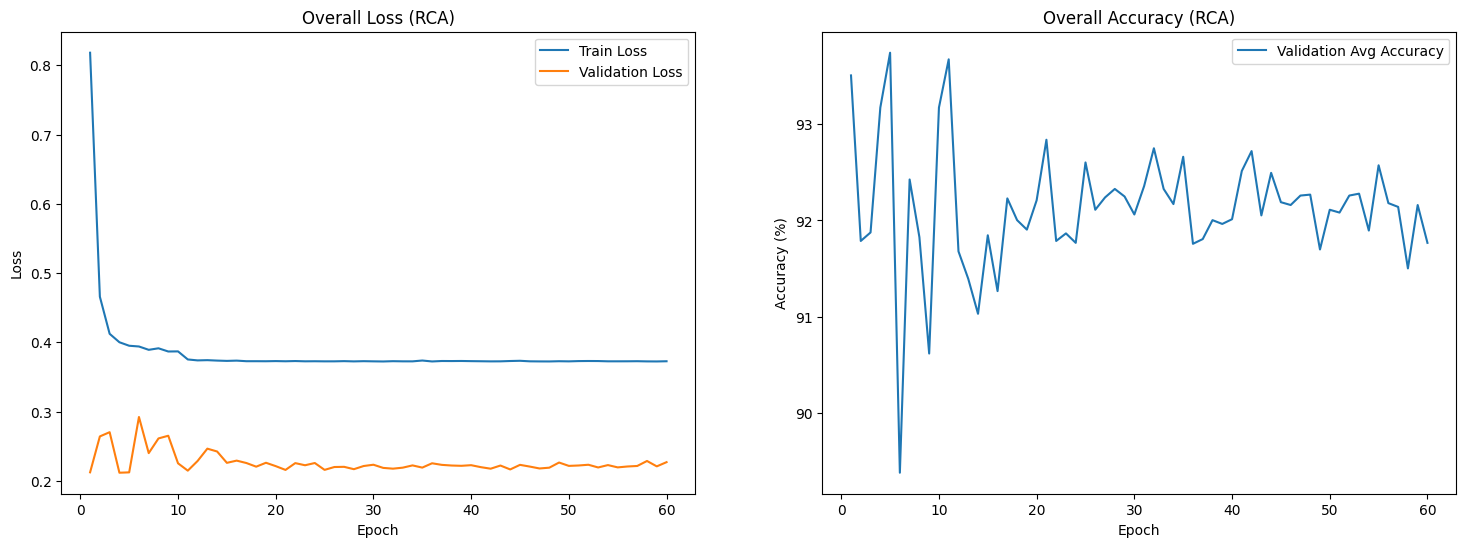

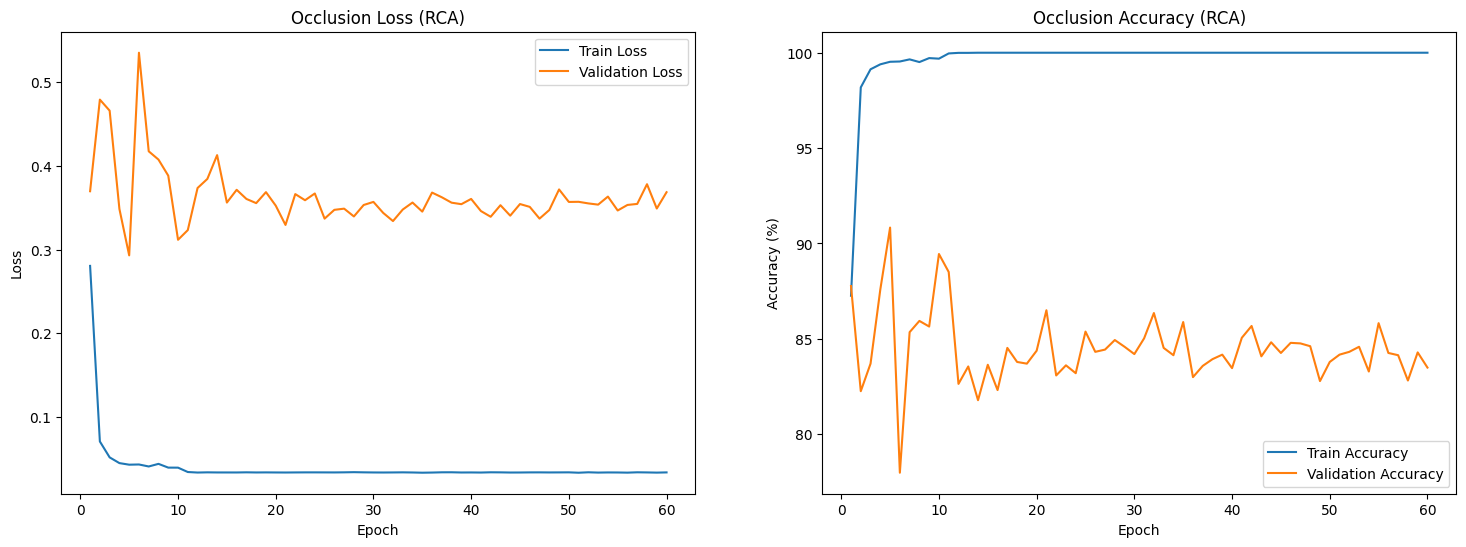

KeyError: 'Train_frame_Loss'

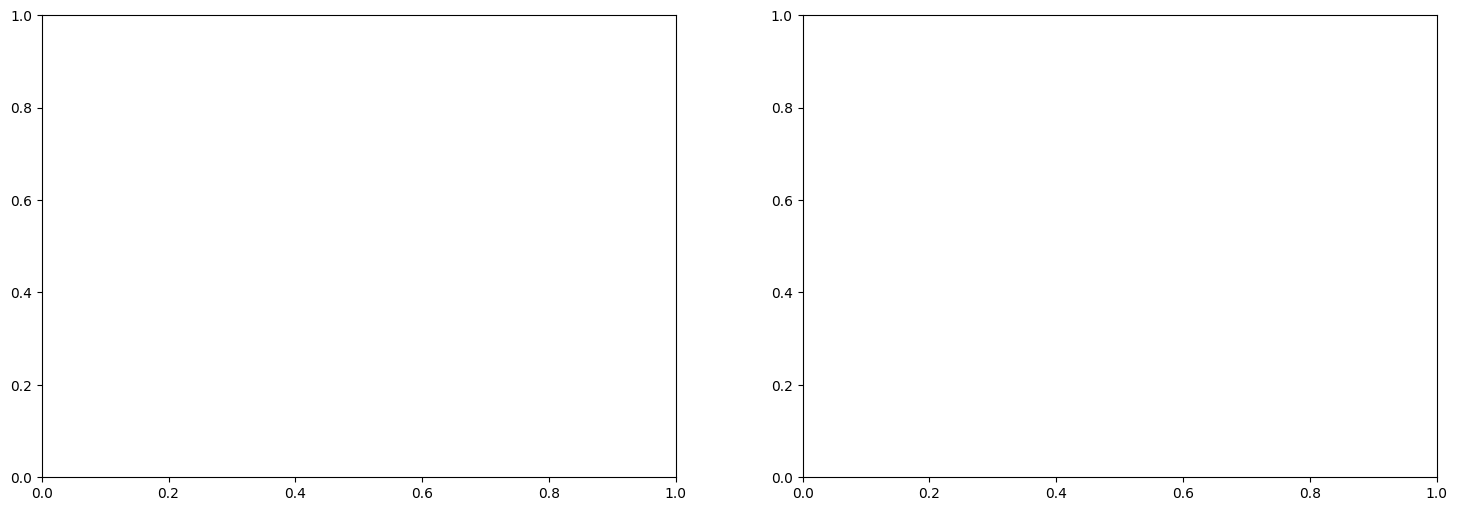

In [26]:
plot_training_history(history_df, 'RCA', save_dir=r'E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_Resnet18_LSTM\training_results\plots')

In [ ]:
plot_save_dir = os.path.join(CHECKPOINT_PATH, 'plots')
plot_training_history(history_df, VIEW_TO_TRAIN, save_dir=plot_save_dir)

# INFERENCE

In [32]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_recall_fscore_support,
                           precision_score, recall_score, f1_score)
from timeit import default_timer as timer
import re
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

## EVALUATION FUNCTION

#### old eval

In [ ]:
def evaluate_model_optimized(model, test_dl, criteria, device, view_to_train, ignore_label_value, categories_map, is_training=False):
    """Optimized evaluation function."""
    model.eval()
    active_tasks = ['frame_quality', 'dominance']
    if view_to_train == 'RCA':
        active_tasks.insert(0, 'occlusion')

    task_results = {task: {'targets': [], 'preds': [], 'loss': 0, 'batches': 0} for task in active_tasks}

    total_time, num_batches = 0, 0

    with torch.no_grad():
        for data in tqdm(test_dl, desc=f"Evaluating ({view_to_train})", disable=is_training):
            inputs = {k: v.to(device, non_blocking=True) for k, v in data['inputs'].items() if v.nelement() > 0}
            labels = {k: v.to(device, non_blocking=True) for k, v in data['labels'].items() if v.nelement() > 0}

            if not labels:
                continue

            num_batches += 1
            start_time = timer()

            with torch.amp.autocast('cuda'):
                outputs = model(inputs)

            torch.cuda.synchronize()
            total_time += (timer() - start_time)

            for task, logits in outputs.items():
                if task not in labels:
                    continue
                if task == 'occlusion' and view_to_train != 'RCA':
                    continue

                logits_for_loss = logits.squeeze(1)
                loss = criteria[task](logits_for_loss, labels[task])

                task_results[task]['loss'] += loss.item()
                task_results[task]['batches'] += 1

                _, preds = torch.max(logits_for_loss, 1)

                valid_indices = labels[task] != ignore_label_value
                task_results[task]['targets'].extend(labels[task][valid_indices].cpu().numpy())
                task_results[task]['preds'].extend(preds[valid_indices].cpu().numpy())

    # Compute final results
    final_report = {
        'inference_time_per_batch_ms': (total_time / num_batches) * 1000 if num_batches > 0 else 0,
        'peak_gpu_memory_mb': torch.cuda.max_memory_allocated(device) / (1024**2) if device.type == 'cuda' else 0
    }

    total_loss, accs = 0, []
    for task in active_tasks:
        targets = np.array(task_results[task]['targets'])
        preds = np.array(task_results[task]['preds'])

        if len(targets) == 0:
            continue

        avg_loss = task_results[task]['loss'] / task_results[task]['batches'] if task_results[task]['batches'] > 0 else 0
        acc = np.mean(targets == preds)

        total_loss += avg_loss
        accs.append(acc)

        final_report[task] = {
            'test_loss': avg_loss,
            'test_acc': acc,
            'all_targets': targets,
            'prediction_labels': preds,
            'confusion_matrix': confusion_matrix(targets, preds, labels=np.arange(len(categories_map[task]))),
            'classification_report': classification_report(targets, preds, target_names=categories_map[task], digits=4, output_dict=True, zero_division=0)
        }

    final_report['overall_loss'] = total_loss / len(accs) if accs else 0
    final_report['overall_test_accuracy'] = np.mean(accs) * 100 if accs else 0

    if not is_training:
        print(f"\nINFERENCE REPORT ({view_to_train}): Time/batch: {final_report['inference_time_per_batch_ms']:.2f}ms | Peak GPU: {final_report['peak_gpu_memory_mb']:.2f}MB")
        for task in active_tasks:
            if task in final_report:
                print(f"--- {task.title()} ---\nAcc: {final_report[task]['test_acc']*100:.2f}%")
                print(pd.DataFrame(final_report[task]['classification_report']).transpose().to_string())

    return final_report


#### New eval

In [34]:
def evaluate_model_corrected(model, test_dl, criteria, device, view_to_train, ignore_label_value, categories_map, dataset, is_training=False):
    """Corrected evaluation function that respects actual task distributions."""
    model.eval()
    active_tasks = ['frame_quality', 'dominance']
    if view_to_train == 'RCA':
        active_tasks.insert(0, 'occlusion')

    # Track seen samples to avoid double counting
    task_seen_samples = {task: set() for task in active_tasks}
    task_results = {task: {'targets': [], 'preds': [], 'loss': 0, 'batches': 0} for task in active_tasks}

    total_time, num_batches = 0, 0

    with torch.no_grad():
        for batch_idx, data in enumerate(tqdm(test_dl, desc=f"Evaluating ({view_to_train})", disable=is_training)):
            inputs = {k: v.to(device, non_blocking=True) for k, v in data['inputs'].items() if v.nelement() > 0}
            labels = {k: v.to(device, non_blocking=True) for k, v in data['labels'].items() if v.nelement() > 0}

            if not labels:
                continue

            num_batches += 1
            start_time = timer()

            with torch.amp.autocast('cuda'):
                outputs = model(inputs)

            torch.cuda.synchronize()
            total_time += (timer() - start_time)

            batch_size = next(iter(labels.values())).size(0)

            for task, logits in outputs.items():
                if task not in labels:
                    continue
                if task == 'occlusion' and view_to_train != 'RCA':
                    continue

                logits_for_loss = logits.squeeze(1)
                loss = criteria[task](logits_for_loss, labels[task])

                task_results[task]['loss'] += loss.item()
                task_results[task]['batches'] += 1

                _, preds = torch.max(logits_for_loss, 1)

                # Only process valid labels (not ignore values)
                valid_indices = labels[task] != ignore_label_value
                
                if valid_indices.any():
                    valid_targets = labels[task][valid_indices].cpu().numpy()
                    valid_preds = preds[valid_indices].cpu().numpy()
                    
                    # For proper distribution tracking, we need to consider task-specific sampling
                    for i, (target, pred) in enumerate(zip(valid_targets, valid_preds)):
                        # Create a unique identifier for this sample within the batch
                        sample_id = f"{batch_idx}_{i}_{task}"
                        
                        if sample_id not in task_seen_samples[task]:
                            task_seen_samples[task].add(sample_id)
                            task_results[task]['targets'].append(target)
                            task_results[task]['preds'].append(pred)

    # Compute final results
    final_report = {
        'inference_time_per_batch_ms': (total_time / num_batches) * 1000 if num_batches > 0 else 0,
        'peak_gpu_memory_mb': torch.cuda.max_memory_allocated(device) / (1024**2) if device.type == 'cuda' else 0
    }

    total_loss, accs = 0, []
    
    # Get actual task distributions from dataset
    actual_distributions = dataset.get_task_distribution()
    
    for task in active_tasks:
        targets = np.array(task_results[task]['targets'])
        preds = np.array(task_results[task]['preds'])

        if len(targets) == 0:
            continue

        avg_loss = task_results[task]['loss'] / task_results[task]['batches'] if task_results[task]['batches'] > 0 else 0
        acc = np.mean(targets == preds)

        total_loss += avg_loss
        accs.append(acc)

        # Report actual vs processed counts
        actual_count = actual_distributions.get(task, {}).get('total', 0)
        processed_count = len(targets)
        
        print(f"\n{task.upper()} - Actual: {actual_count}, Processed: {processed_count}")

        final_report[task] = {
            'test_loss': avg_loss,
            'test_acc': acc,
            'all_targets': targets,
            'prediction_labels': preds,
            'actual_sample_count': actual_count,
            'processed_sample_count': processed_count,
            'confusion_matrix': confusion_matrix(targets, preds, labels=np.arange(len(categories_map[task]))),
            'classification_report': classification_report(targets, preds, target_names=categories_map[task], digits=4, output_dict=True, zero_division=0)
        }

    final_report['overall_loss'] = total_loss / len(accs) if accs else 0
    final_report['overall_test_accuracy'] = np.mean(accs) * 100 if accs else 0

    if not is_training:
        print(f"\nINFERENCE REPORT ({view_to_train}): Time/batch: {final_report['inference_time_per_batch_ms']:.2f}ms | Peak GPU: {final_report['peak_gpu_memory_mb']:.2f}MB")
        for task in active_tasks:
            if task in final_report:
                print(f"--- {task.title()} ---\nAcc: {final_report[task]['test_acc']*100:.2f}%")
                print(pd.DataFrame(final_report[task]['classification_report']).transpose().to_string())

    return final_report

## DATALOADER

In [35]:
class OptimizedTemporalMTDDataset(Dataset):
    """Corrected dataset that handles different sample counts per task properly."""

    def __init__(self, root_dir, split_type, view_type, clip_length, transform=None, fold_num=1):
        self.root_dir = root_dir
        self.split_type = split_type
        self.view_type = view_type
        self.clip_length = clip_length
        self.transform = transform
        self.fold_num = fold_num
        self.IGNORE_LABEL_VALUE = -1

        # Label mappings
        self.occlusion_label_map = {'nonoccluded': 0, 'occluded': 1}
        self.frame_quality_label_map = {'noninformative': 0, 'informative': 1}
        self.dominance_label_map = {'rightdom': 0, 'leftdom': 1}

        # Data structures for each task
        self.occlusion_clips = []  # Video clips for occlusion
        self.frame_quality_samples = []  # Individual frames for frame quality
        self.dominance_samples = []  # Individual frames for dominance
        
        # Track which tasks are available
        self.available_tasks = []

        self._load_all_tasks()

    def _load_all_tasks(self):
        """Load all tasks independently without artificial balancing."""
        print(f"--- Loading {self.split_type} data for {self.view_type} view ---")

        # Load occlusion data (only for RCA view)
        if self.view_type == 'RCA':
            self._load_occlusion_data()
            if self.occlusion_clips:
                self.available_tasks.append('occlusion')

        # Load frame quality data
        self._load_frame_quality_data()
        if self.frame_quality_samples:
            self.available_tasks.append('frame_quality')

        # Load dominance data
        self._load_dominance_data()
        if self.dominance_samples:
            self.available_tasks.append('dominance')

        print(f"Available tasks: {self.available_tasks}")
        print(f"Occlusion clips: {len(self.occlusion_clips)}")
        print(f"Frame quality samples: {len(self.frame_quality_samples)}")
        print(f"Dominance samples: {len(self.dominance_samples)}")

    def _load_occlusion_data(self):
        """Load occlusion task data (RCA only)."""
        csv_path = os.path.join(
            self.root_dir, 'occlusion', 'DATA_RCA', 'labels', 
            f'occlusion_{self.split_type}_labels_fold_{self.fold_num}.csv'
        )

        if not os.path.exists(csv_path):
            print(f"Occlusion CSV not found: {csv_path}")
            return

        df = pd.read_csv(csv_path)
        
        # Group frames by video
        video_frames = defaultdict(list)
        
        for _, row in df.iterrows():
            filename = str(row['filename'])
            label_str = str(row['label']).strip().lower()
            label = self.occlusion_label_map.get(label_str)

            if label is None:
                continue

            # Extract video ID from filename
            match = re.match(r'(.+)_frame_(\d+)\.png', filename)
            if match:
                video_id = match.group(1)
                frame_idx = int(match.group(2))
                
                path = os.path.join(self.root_dir, 'occlusion', 'DATA_RCA', label_str, filename)
                if os.path.exists(path):
                    video_frames[video_id].append((frame_idx, path, label, filename))

        # Create clips from videos
        for video_id, frames in video_frames.items():
            frames.sort(key=lambda x: x[0])  # Sort by frame index

            if len(frames) >= self.clip_length:
                # For inference, use non-overlapping clips to get true video count
                for i in range(0, len(frames) - self.clip_length + 1, self.clip_length):
                    clip_frames = frames[i:i + self.clip_length]
                    self.occlusion_clips.append({
                        'video_id': video_id,
                        'frames': clip_frames,
                        'label': clip_frames[-1][2]  # Use last frame's label
                    })

        print(f"Created {len(self.occlusion_clips)} occlusion clips from {len(video_frames)} videos")

    def _load_frame_quality_data(self):
        """Load frame quality task data."""
        csv_path = os.path.join(
            self.root_dir, 'framequality', f'DATA_{self.view_type}', 'labels',
            f'framequality_{self.split_type}_labels_fold_{self.fold_num}.csv'
        )

        if not os.path.exists(csv_path):
            print(f"Frame quality CSV not found: {csv_path}")
            return

        df = pd.read_csv(csv_path)

        for _, row in df.iterrows():
            filename = str(row['filename'])
            label_str = str(row['label']).strip().lower()
            label = self.frame_quality_label_map.get(label_str)

            if label is None:
                continue

            path = os.path.join(self.root_dir, 'framequality', f'DATA_{self.view_type}', label_str, filename)
            if os.path.exists(path):
                self.frame_quality_samples.append((path, label, filename))

        print(f"Loaded {len(self.frame_quality_samples)} frame quality samples")

    def _load_dominance_data(self):
        """Load dominance task data."""
        csv_path = os.path.join(
            self.root_dir, 'dominance', f'DATA_{self.view_type}', 'labels',
            f'dom_{self.split_type}_labels_fold_{self.fold_num}.csv'
        )

        if not os.path.exists(csv_path):
            print(f"Dominance CSV not found: {csv_path}")
            return

        df = pd.read_csv(csv_path)

        for _, row in df.iterrows():
            filename = str(row['filename'])
            label_str = str(row['label']).strip().lower()
            label = self.dominance_label_map.get(label_str)

            if label is None:
                continue

            path = os.path.join(self.root_dir, 'dominance', f'DATA_{self.view_type}', label_str, filename)
            if os.path.exists(path):
                self.dominance_samples.append((path, label, filename))

        print(f"Loaded {len(self.dominance_samples)} dominance samples")

    def __len__(self):
        """Return the maximum length among available tasks."""
        lengths = []
        if 'occlusion' in self.available_tasks:
            lengths.append(len(self.occlusion_clips))
        if 'frame_quality' in self.available_tasks:
            lengths.append(len(self.frame_quality_samples))
        if 'dominance' in self.available_tasks:
            lengths.append(len(self.dominance_samples))
        
        return max(lengths) if lengths else 0

    def __getitem__(self, idx):
        """Get item with proper task-specific indexing."""
        
        # Initialize with ignore values
        occ_clip = torch.zeros(0, self.clip_length, 1, 512, 512)
        occ_label = torch.tensor(self.IGNORE_LABEL_VALUE, dtype=torch.long)
        
        fq_image = torch.zeros(0, 1, 512, 512)
        fq_label = torch.tensor(self.IGNORE_LABEL_VALUE, dtype=torch.long)
        
        dom_image = torch.zeros(0, 1, 512, 512)
        dom_label = torch.tensor(self.IGNORE_LABEL_VALUE, dtype=torch.long)

        # Get occlusion data (with cycling if needed)
        if 'occlusion' in self.available_tasks and len(self.occlusion_clips) > 0:
            occ_idx = idx % len(self.occlusion_clips)
            occ_clip, occ_label = self._get_occlusion_clip(self.occlusion_clips[occ_idx])

        # Get frame quality data (with cycling if needed)
        if 'frame_quality' in self.available_tasks and len(self.frame_quality_samples) > 0:
            fq_idx = idx % len(self.frame_quality_samples)
            fq_image, fq_label = self._get_single_frame_task(self.frame_quality_samples[fq_idx])

        # Get dominance data (with cycling if needed)
        if 'dominance' in self.available_tasks and len(self.dominance_samples) > 0:
            dom_idx = idx % len(self.dominance_samples)
            dom_image, dom_label = self._get_single_frame_task(self.dominance_samples[dom_idx])

        return {
            'inputs': {
                'occlusion_images': occ_clip,
                'frame_quality_images': fq_image,
                'dominance_images': dom_image
            },
            'labels': {
                'occlusion': occ_label,
                'frame_quality': fq_label,
                'dominance': dom_label
            }
        }

    def _get_occlusion_clip(self, clip_data):
        """Get occlusion clip."""
        try:
            clip_frames = []
            for _, path, _, _ in clip_data['frames']:
                with Image.open(path) as img:
                    img = img.convert('L')
                    if self.transform:
                        img = self.transform(img)
                    clip_frames.append(img)

            clip_tensor = torch.stack(clip_frames)
            label = torch.tensor(clip_data['label'], dtype=torch.long)

            return clip_tensor, label

        except Exception as e:
            print(f"Error loading occlusion clip: {e}")
            return torch.zeros(0, self.clip_length, 1, 512, 512), torch.tensor(self.IGNORE_LABEL_VALUE, dtype=torch.long)

    def _get_single_frame_task(self, task_data):
        """Get single frame task data."""
        try:
            path, label, _ = task_data
            with Image.open(path) as img:
                img = img.convert('L')
                if self.transform:
                    img = self.transform(img)

            return img, torch.tensor(label, dtype=torch.long)

        except Exception as e:
            print(f"Error loading single frame: {e}")
            return torch.zeros(0, 1, 512, 512), torch.tensor(self.IGNORE_LABEL_VALUE, dtype=torch.long)

    def get_task_distribution(self):
        """Get the actual distribution of each task."""
        distribution = {}
        
        if 'occlusion' in self.available_tasks:
            occ_labels = [clip['label'] for clip in self.occlusion_clips]
            unique, counts = np.unique(occ_labels, return_counts=True)
            distribution['occlusion'] = {
                'total': len(self.occlusion_clips),
                'classes': dict(zip(unique, counts)),
                'unit': 'videos'
            }
        
        if 'frame_quality' in self.available_tasks:
            fq_labels = [sample[1] for sample in self.frame_quality_samples]
            unique, counts = np.unique(fq_labels, return_counts=True)
            distribution['frame_quality'] = {
                'total': len(self.frame_quality_samples),
                'classes': dict(zip(unique, counts)),
                'unit': 'frames'
            }
        
        if 'dominance' in self.available_tasks:
            dom_labels = [sample[1] for sample in self.dominance_samples]
            unique, counts = np.unique(dom_labels, return_counts=True)
            distribution['dominance'] = {
                'total': len(self.dominance_samples),
                'classes': dict(zip(unique, counts)),
                'unit': 'frames'
            }
        
        return distribution

## NECESSARY FUNCTIONS

In [30]:
def calculate_advanced_metrics(y_true, y_pred, task_name,categories_map):
        """Calculate comprehensive metrics for a task"""
        
        # Basic metrics
        accuracy = accuracy_score(y_true, y_pred) * 100
        
        # Per-class metrics
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, average=None, zero_division=0
        )
        
        # Macro averages
        precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0) * 100
        recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0) * 100
        f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100
        
        # Calculate specificity for each class
        cm = confusion_matrix(y_true, y_pred)
        specificities = []
        
        for i in range(len(categories_map[task_name])):
            if cm.shape[0] > 1:  # Ensure we have multiple classes
                tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
                fp = np.sum(cm[:, i]) - cm[i, i]
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                specificities.append(specificity * 100)
            else:
                specificities.append(0.0)
        
        specificity_macro = np.mean(specificities)
        
        # Create detailed metrics dictionary
        metrics = {
            'Overall_Accuracy': accuracy,
            'Macro_Precision': precision_macro,
            'Macro_Recall': recall_macro,
            'Macro_F1_Score': f1_macro,
            'Macro_Specificity': specificity_macro,
            'Total_Samples': len(y_true)
        }
        
        # Add per-class metrics
        for i, class_name in enumerate(categories_map[task_name]):
            if i < len(precision):
                metrics[f'{class_name}_Precision'] = precision[i] * 100
                metrics[f'{class_name}_Recall'] = recall[i] * 100
                metrics[f'{class_name}_F1_Score'] = f1[i] * 100
                metrics[f'{class_name}_Specificity'] = specificities[i]
                metrics[f'{class_name}_Support'] = support[i]
        
        return metrics

In [37]:
def create_confusion_matrix_plot(y_true, y_pred, task_name, save_path,categories_map,view_type,fold_num = 1):
        """Create and save confusion matrix plot"""
        
        cm = confusion_matrix(y_true, y_pred)
        
        plt.figure(figsize=(10, 8))
        
        # Create heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=categories_map[task_name],
                   yticklabels=categories_map[task_name],
                   cbar_kws={'label': 'Count'})
        
        plt.title(f'Confusion Matrix - {task_name.title()} Task\n'
                 f'View: {view_type} | Fold: {fold_num}', 
                 fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        
        # Add accuracy on the plot
        #accuracy = accuracy_score(y_true, y_pred) * 100
        #plt.figtext(0.02, 0.02, f'Overall Accuracy: {accuracy:.2f}%', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Confusion matrix saved: {save_path}")
    
def generate_classification_report(final_report, save_path,categories_map,view_type,fold_num = 1):
    """Generate and save comprehensive classification reports"""
    
    reports = {}
    
    # Extract task results from final_report (similar to evaluate_model_optimized output)
    for task_name in categories_map.keys():
        if task_name in final_report and isinstance(final_report[task_name], dict):
            if 'all_targets' in final_report[task_name] and len(final_report[task_name]['all_targets']) > 0:
                # Use the classification report already generated by run_inference
                reports[task_name] = final_report[task_name]['classification_report']
                
                y_true = final_report[task_name]['all_targets']
                y_pred = final_report[task_name]['prediction_labels']
                
                # Print report to console (additional to what's already printed)
                print(f"\n{'='*60}")
                print(f"DETAILED CLASSIFICATION REPORT - {task_name.upper()} TASK")
                print(f"{'='*60}")
                print(f"View: {view_type} | Fold: {fold_num}")
                print(f"Total samples: {len(y_true)}")
                
                if task_name == 'occlusion':
                    print("(Videos)")
                else:
                    print("(Frames)")
                
                print(f"\nTest Loss: {final_report[task_name]['test_loss']:.4f}")
                print(f"Test Accuracy: {final_report[task_name]['test_acc']*100:.2f}%")
    
    # Save reports to file
    with open(save_path, 'w') as f:
        f.write(f"CLASSIFICATION REPORTS\n")
        f.write(f"View: {view_type} | Fold: {fold_num}\n")
        f.write(f"="*80 + "\n\n")
        
        f.write(f"OVERALL PERFORMANCE\n")
        f.write(f"-"*40 + "\n")
        f.write(f"Overall Loss: {final_report.get('overall_loss', 0):.4f}\n")
        f.write(f"Overall Accuracy: {final_report.get('overall_test_accuracy', 0):.2f}%\n")
        f.write(f"Inference Time per Batch: {final_report.get('inference_time_per_batch_ms', 0):.2f}ms\n")
        f.write(f"Peak GPU Memory: {final_report.get('peak_gpu_memory_mb', 0):.2f}MB\n\n")
        
        for task_name in categories_map.keys():
            if task_name in final_report and isinstance(final_report[task_name], dict):
                if 'all_targets' in final_report[task_name] and len(final_report[task_name]['all_targets']) > 0:
                    f.write(f"{task_name.upper()} TASK\n")
                    f.write(f"-"*40 + "\n")
                    
                    y_true = final_report[task_name]['all_targets']
                    y_pred = final_report[task_name]['prediction_labels']
                    
                    f.write(f"Test Loss: {final_report[task_name]['test_loss']:.4f}\n")
                    f.write(f"Test Accuracy: {final_report[task_name]['test_acc']*100:.2f}%\n")
                    f.write(f"Total Samples: {len(y_true)}\n\n")
                    
                    f.write(classification_report(
                        y_true, y_pred,
                        target_names=categories_map[task_name],
                        digits=4,
                        zero_division=0
                    ))
                    f.write("\n" + "="*80 + "\n\n")
    
    print(f"Classification reports saved: {save_path}")
    return reports
    
def save_advanced_metrics_excel( final_report, save_path,categories_map,view_type,fold_num =1):
    """Save advanced metrics to Excel file"""
    
    with pd.ExcelWriter(save_path, engine='openpyxl') as writer:
        summary_data = []
        
        for task_name in categories_map.keys():
            if task_name in final_report and isinstance(final_report[task_name], dict):
                if 'all_targets' in final_report[task_name] and len(final_report[task_name]['all_targets']) > 0:
                    
                    y_true = final_report[task_name]['all_targets']
                    y_pred = final_report[task_name]['prediction_labels']
                    
                    # Calculate advanced metrics
                    metrics = calculate_advanced_metrics(y_true, y_pred, task_name,categories_map)
                    
                    # Add task info and values from final_report
                    metrics['Task'] = task_name.title()
                    metrics['View'] = view_type
                    metrics['Fold'] = fold_num
                    metrics['Test_Loss'] = final_report[task_name]['test_loss']
                    
                    summary_data.append(metrics)
                    
                    # Create detailed DataFrame for this task
                    detailed_df = pd.DataFrame([metrics])
                    detailed_df = detailed_df.round(4)
                    
                    # Save to separate sheet
                    sheet_name = f"{task_name.title()}_Metrics"
                    detailed_df.to_excel(writer, sheet_name=sheet_name, index=False)
        
        # Create summary sheet
        if summary_data:
            summary_df = pd.DataFrame(summary_data)
            
            # Reorder columns
            cols = ['Task', 'View', 'Fold', 'Total_Samples', 'Test_Loss', 'Overall_Accuracy', 
                    'Macro_Precision', 'Macro_Recall', 'Macro_F1_Score', 'Macro_Specificity']
            other_cols = [col for col in summary_df.columns if col not in cols]
            final_cols = cols + other_cols
            
            summary_df = summary_df[final_cols]
            summary_df = summary_df.round(4)
            
            summary_df.to_excel(writer, sheet_name='Summary', index=False)
            
            # Add overall performance sheet
            overall_data = {
                'Metric': ['Overall Loss', 'Overall Accuracy (%)', 'Inference Time (ms/batch)', 'Peak GPU Memory (MB)'],
                'Value': [
                    final_report.get('overall_loss', 0),
                    final_report.get('overall_test_accuracy', 0),
                    final_report.get('inference_time_per_batch_ms', 0),
                    final_report.get('peak_gpu_memory_mb', 0)
                ]
            }
            overall_df = pd.DataFrame(overall_data)
            overall_df.to_excel(writer, sheet_name='Overall_Performance', index=False)
    
    print(f"Advanced metrics saved to Excel: {save_path}")


## VALIDATE DISTRIBUTION

### old validate

In [31]:
def validate_test_distribution(final_report,categories_map):
        """Validate that test results match expected distribution"""
        
        expected_distributions = {
            'occlusion': {'nonoccluded': 59, 'occluded': 48, 'total': 107, 'unit': 'videos'},
            'frame_quality': {'informative': 442, 'non-informative': 347, 'total': 789, 'unit': 'frames'},
            'dominance': {'rightdom': 3681, 'leftdom': 468, 'total': 4149, 'unit': 'frames'}
        }
        
        print(f"\n{'='*80}")
        print("TEST SET DISTRIBUTION VALIDATION")
        print(f"{'='*80}")
        
        for task_name in categories_map.keys():
            if task_name in final_report and isinstance(final_report[task_name], dict):
                if 'all_targets' in final_report[task_name] and len(final_report[task_name]['all_targets']) > 0:
                    
                    y_true = final_report[task_name]['all_targets']
                    actual_total = len(y_true)
                    
                    print(f"\n--- {task_name.upper()} TASK ---")
                    
                    if task_name in expected_distributions:
                        expected = expected_distributions[task_name]
                        print(f"Expected total: {expected['total']} {expected['unit']}")
                        print(f"Actual total: {actual_total} samples")
                        
                        # Count per class
                        unique, counts = np.unique(y_true, return_counts=True)
                        actual_dist = dict(zip(unique, counts))
                        
                        for class_idx, class_name in enumerate(categories_map[task_name]):
                            actual_count = actual_dist.get(class_idx, 0)
                            print(f"  {class_name}: {actual_count} samples")
                        
                        # Validation status
                        if actual_total == expected['total']:
                            print("✅ Distribution matches expected!")
                        else:
                            print("⚠️  Distribution mismatch!")
                    else:
                        print(f"No expected distribution defined for {task_name}")

### New validate

In [63]:
def validate_test_distribution_corrected(final_report, categories_map, dataset):
    """Corrected validation using actual dataset distributions."""
    
    expected_distributions = {
        'occlusion': {'nonoccluded': 59, 'occluded': 48, 'total': 107, 'unit': 'videos'},
        'frame_quality': {'informative': 442, 'non-informative': 347, 'total': 789, 'unit': 'frames'},
        'dominance': {'rightdom': 3681, 'leftdom': 468, 'total': 4149, 'unit': 'frames'}
    }
    
    # Get actual distributions from dataset
    actual_distributions = dataset.get_task_distribution()
    
    print(f"\n{'='*80}")
    print("CORRECTED TEST SET DISTRIBUTION VALIDATION")
    print(f"{'='*80}")
    
    for task_name in categories_map.keys():
        if task_name in actual_distributions:
            actual_dist = actual_distributions[task_name]
            
            print(f"\n--- {task_name.upper()} TASK ---")
            print(f"Dataset contains: {actual_dist['total']} {actual_dist['unit']}")
            
            if task_name in expected_distributions:
                expected = expected_distributions[task_name]
                print(f"Expected: {expected['total']} {expected['unit']}")
                
                # Class distribution
                class_names = categories_map[task_name]
                for class_idx, class_name in enumerate(class_names):
                    actual_count = actual_dist['classes'].get(class_idx, 0)
                    print(f"  {class_name}: {actual_count} {actual_dist['unit']}")
                
                if actual_dist['total'] == expected['total']:
                    print("✅ Distribution matches expected!")
                else:
                    print("⚠️  Distribution mismatch!")
            
            # Show what was processed during evaluation
            if task_name in final_report:
                processed_count = final_report[task_name].get('processed_sample_count', 0)
                print(f"Processed during evaluation: {processed_count} samples")
        else:
            print(f"\n--- {task_name.upper()} TASK ---")
            print("No data found for this task")

## PERFORM INFERENCE

In [38]:
VIEW_TYPE = 'RCA'
DATA_ROOT = r'E:\Morshedul\CoronarDominance\MTL_DATASET'
FOLD_NUM = 1
BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2
CLIP_LENGTH = 15
IMAGE_SIZE = 512
NUM_WORKERS = 0
IGNORE_LABELS = -1
IS_TRAINING = False
MEAN, STD = 0.5485, 0.1407


In [39]:
# Optimized data loading
print("Setting up optimized data loading...")
transform = OptimizedClipAndFrameTransform((IMAGE_SIZE, IMAGE_SIZE), mean=[MEAN], std=[STD])

test_dataset = OptimizedTemporalMTDDataset(DATA_ROOT, 'test', VIEW_TO_TRAIN, CLIP_LENGTH, transform, FOLD_NUM)

# Optimized data loaders
test_dl = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    collate_fn=collate_fn_optimized,
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)


print(f"Test dataset loaded with {len(test_dataset)} samples")

Setting up optimized data loading...
--- Loading test data for RCA view ---
Created 296 occlusion clips from 107 videos
Loaded 789 frame quality samples
Loaded 4149 dominance samples
Available tasks: ['occlusion', 'frame_quality', 'dominance']
Occlusion clips: 296
Frame quality samples: 789
Dominance samples: 4149
Test dataset loaded with 4149 samples


In [41]:
output_dir = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_Densenet121_LSTM\testing_results'
os.makedirs(output_dir, exist_ok=True)

In [44]:
BACKBONE_TYPE = "densenet"
INPUT_CHANNELS = 1
NUM_CLASSES_OCCLUSION = 2
NUM_CLASSES_FRAMEQUALITY = 2
NUM_CLASSES_DOMINANCE = 2
HIDDEN_DIM = 128
SEQUENTIAL_HIDDEN_DIM = 128
SEQUENTIAL_MODEL_TYPE = 'lstm'
NUM_SEQUENTIAL_LAYERS = 5
BIDIRECTIONAL = False
MODEL_PATH = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_Densenet121_LSTM\training_results\TemporalMTD_Densenet121_fold1_best.pth'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#backbone = models.resnet18(weights="DEFAULT")
backbone = models.densenet121(weights='DEFAULT', memory_efficient=True)
model = OptimizedTemporalMultiTaskStudent(
    backbone=backbone,
    backbone_type=BACKBONE_TYPE,
    input_channels=INPUT_CHANNELS,
    num_classes_occlusion=NUM_CLASSES_OCCLUSION,
    num_classes_frame_quality=NUM_CLASSES_FRAMEQUALITY,
    num_classes_dominance=NUM_CLASSES_DOMINANCE,
    hidden_dim=HIDDEN_DIM,
    sequential_model_type=SEQUENTIAL_MODEL_TYPE,
    sequential_hidden_dim=SEQUENTIAL_HIDDEN_DIM,
    num_sequential_layers=NUM_SEQUENTIAL_LAYERS,
    bidirectional=BIDIRECTIONAL,
).to(device)


# Load checkpoint
if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded model from epoch {checkpoint.get('epoch', 'unknown')}")
    else:
        model.load_state_dict(checkpoint)
    
    model.eval()
    print("Model loaded successfully!")
else:
    raise FileNotFoundError(f"Model checkpoint not found at: {MODEL_PATH}")


Using device: cuda
Loaded model from epoch 7
Model loaded successfully!


In [45]:
categories_map = {'occlusion': ['nonoccluded', 'occluded'], 'frame_quality': ['noninformative', 'informative'], 'dominance': ['rightdom', 'leftdom']}
criterions = {task: nn.CrossEntropyLoss(ignore_index=-1) for task in categories_map.keys()}

In [46]:
#final_report = evaluate_model_optimized(model, test_dl, criterions, device, VIEW_TYPE, IGNORE_LABELS, categories_map, is_training=IS_TRAINING)
final_report  = evaluate_model_corrected(model, test_dl, criterions, device, VIEW_TYPE, IGNORE_LABELS, categories_map, test_dataset,is_training=IS_TRAINING)

Evaluating (RCA): 100%|███████████████████████████████| 1038/1038 [10:50<00:00,  1.60it/s]


OCCLUSION - Actual: 296, Processed: 4149

FRAME_QUALITY - Actual: 789, Processed: 4149

DOMINANCE - Actual: 4149, Processed: 4149

INFERENCE REPORT (RCA): Time/batch: 140.33ms | Peak GPU: 2094.33MB
--- Occlusion ---
Acc: 84.45%
              precision    recall  f1-score      support
nonoccluded    0.838979  0.827338  0.833118  1946.000000
occluded       0.849327  0.859737  0.854500  2203.000000
accuracy       0.844541  0.844541  0.844541     0.844541
macro avg      0.844153  0.843537  0.843809  4149.000000
weighted avg   0.844474  0.844541  0.844471  4149.000000
--- Frame_Quality ---
Acc: 87.64%
                precision    recall  f1-score      support
noninformative   0.796890  0.945245  0.864751  1735.000000
informative      0.954567  0.826843  0.886127  2414.000000
accuracy         0.876356  0.876356  0.876356     0.876356
macro avg        0.875729  0.886044  0.875439  4149.000000
weighted avg     0.888631  0.876356  0.877188  4149.000000
--- Dominance ---
Acc: 97.88%
           

In [70]:
#validate_test_distribution(final_report,categories_map)
validate_test_distribution_corrected(final_report, categories_map, test_dataset)


CORRECTED TEST SET DISTRIBUTION VALIDATION

--- OCCLUSION TASK ---
Dataset contains: 296 videos
Expected: 107 videos
  nonoccluded: 139 videos
  occluded: 157 videos
⚠️  Distribution mismatch!
Processed during evaluation: 4149 samples

--- FRAME_QUALITY TASK ---
Dataset contains: 789 frames
Expected: 789 frames
  noninformative: 347 frames
  informative: 442 frames
✅ Distribution matches expected!
Processed during evaluation: 4149 samples

--- DOMINANCE TASK ---
Dataset contains: 4149 frames
Expected: 4149 frames
  rightdom: 3681 frames
  leftdom: 468 frames
✅ Distribution matches expected!
Processed during evaluation: 4149 samples


# NEW INFERENCE

In [31]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_recall_fscore_support,
                           precision_score, recall_score, f1_score)
from timeit import default_timer as timer
import re
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [25]:
class TaskSpecificDataset(Dataset):
    """Dataset that returns samples for a specific task only."""
    
    def __init__(self, root_dir, split_type, view_type, clip_length, task_name, transform=None, fold_num=1):
        self.root_dir = root_dir
        self.split_type = split_type
        self.view_type = view_type
        self.clip_length = clip_length
        self.task_name = task_name
        self.transform = transform
        self.fold_num = fold_num
        self.IGNORE_LABEL_VALUE = -1
        
        # Label mappings
        self.label_maps = {
            'occlusion': {'nonoccluded': 0, 'occluded': 1},
            'frame_quality': {'noninformative': 0, 'informative': 1},
            'dominance': {'rightdom': 0, 'leftdom': 1}
        }
        
        self.samples = []
        self._load_task_data()
    
    def _load_task_data(self):
        """Load data for the specific task."""
        if self.task_name == 'occlusion':
            self._load_occlusion_data()
        elif self.task_name == 'frame_quality':
            self._load_frame_quality_data()
        elif self.task_name == 'dominance':
            self._load_dominance_data()
    
    def _load_occlusion_data(self):
        """Load occlusion clips - ONE CLIP PER VIDEO."""
        if self.view_type != 'RCA':
            return
            
        csv_path = os.path.join(
            self.root_dir, 'occlusion', 'DATA_RCA', 'labels',
            f'occlusion_{self.split_type}_labels_fold_{self.fold_num}.csv'
        )
        
        if not os.path.exists(csv_path):
            return
            
        df = pd.read_csv(csv_path)
        video_frames = defaultdict(list)
        
        for _, row in df.iterrows():
            filename = str(row['filename'])
            label_str = str(row['label']).strip().lower()
            label = self.label_maps['occlusion'].get(label_str)
            
            if label is None:
                continue
                
            match = re.match(r'(.+)_frame_(\d+)\.png', filename)
            if match:
                video_id = match.group(1)
                frame_idx = int(match.group(2))
                path = os.path.join(self.root_dir, 'occlusion', 'DATA_RCA', label_str, filename)
                if os.path.exists(path):
                    video_frames[video_id].append((frame_idx, path, label, filename))
        
        print(f"Found {len(video_frames)} unique videos for occlusion task")
        
        # Create EXACTLY ONE clip per video
        for video_id, frames in video_frames.items():
            frames.sort(key=lambda x: x[0])  # Sort by frame index
            
            if len(frames) >= self.clip_length:
                # Strategy 1: Take middle frames (more representative)
                start_idx = (len(frames) - self.clip_length) // 2
                clip_frames = frames[start_idx:start_idx + self.clip_length]
                
                # Use the most common label in the clip (majority vote)
                labels_in_clip = [frame[2] for frame in clip_frames]
                video_label = max(set(labels_in_clip), key=labels_in_clip.count)
                
                self.samples.append({
                    'type': 'occlusion',
                    'video_id': video_id,
                    'frames': clip_frames,
                    'label': video_label,
                    'total_frames_in_video': len(frames)
                })
            else:
                # If video has fewer frames than clip_length, use all frames
                # and pad or skip based on your preference
                print(f"Warning: Video {video_id} has only {len(frames)} frames (< {self.clip_length})")
                # Option 1: Skip this video
                continue
                # Option 2: Use all frames and pad (uncomment below if needed)
                # clip_frames = frames
                # video_label = max(set([frame[2] for frame in frames]), key=[frame[2] for frame in frames].count)
                # self.samples.append({
                #     'type': 'occlusion',
                #     'video_id': video_id,
                #     'frames': clip_frames,
                #     'label': video_label,
                #     'total_frames_in_video': len(frames)
                # })
        
        print(f"Created {len(self.samples)} occlusion clips (one per video)")
        
        # Verify we have the expected number
        if len(self.samples) != 107:
            print(f"WARNING: Expected 107 videos, but created {len(self.samples)} clips")
            print("This might be due to videos with insufficient frames or data filtering")
    
    def _load_frame_quality_data(self):
        """Load frame quality data."""
        csv_path = os.path.join(
            self.root_dir, 'framequality', f'DATA_{self.view_type}', 'labels',
            f'framequality_{self.split_type}_labels_fold_{self.fold_num}.csv'
        )
        
        if not os.path.exists(csv_path):
            return
            
        df = pd.read_csv(csv_path)
        
        for _, row in df.iterrows():
            filename = str(row['filename'])
            label_str = str(row['label']).strip().lower()
            label = self.label_maps['frame_quality'].get(label_str)
            
            if label is None:
                continue
                
            path = os.path.join(self.root_dir, 'framequality', f'DATA_{self.view_type}', label_str, filename)
            if os.path.exists(path):
                self.samples.append({
                    'type': 'frame_quality',
                    'path': path,
                    'label': label,
                    'filename': filename
                })
    
    def _load_dominance_data(self):
        """Load dominance data."""
        csv_path = os.path.join(
            self.root_dir, 'dominance', f'DATA_{self.view_type}', 'labels',
            f'dom_{self.split_type}_labels_fold_{self.fold_num}.csv'
        )
        
        if not os.path.exists(csv_path):
            return
            
        df = pd.read_csv(csv_path)
        
        for _, row in df.iterrows():
            filename = str(row['filename'])
            label_str = str(row['label']).strip().lower()
            label = self.label_maps['dominance'].get(label_str)
            
            if label is None:
                continue
                
            path = os.path.join(self.root_dir, 'dominance', f'DATA_{self.view_type}', label_str, filename)
            if os.path.exists(path):
                self.samples.append({
                    'type': 'dominance',
                    'path': path,
                    'label': label,
                    'filename': filename
                })
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        if sample['type'] == 'occlusion':
            return self._get_occlusion_sample(sample)
        else:
            return self._get_frame_sample(sample)
    
    def _get_occlusion_sample(self, sample):
        """Get occlusion clip sample."""
        try:
            clip_frames = []
            for _, path, _, _ in sample['frames']:
                with Image.open(path) as img:
                    img = img.convert('L')
                    if self.transform:
                        img = self.transform(img)
                    clip_frames.append(img)
            
            clip_tensor = torch.stack(clip_frames)
            label = torch.tensor(sample['label'], dtype=torch.long)
            
            return {
                'task': 'occlusion',
                'input': clip_tensor,
                'label': label
            }
        except Exception as e:
            print(f"Error loading occlusion clip: {e}")
            return {
                'task': 'occlusion',
                'input': torch.zeros(self.clip_length, 1, 512, 512),
                'label': torch.tensor(self.IGNORE_LABEL_VALUE, dtype=torch.long)
            }
    
    def _get_frame_sample(self, sample):
        """Get single frame sample."""
        try:
            with Image.open(sample['path']) as img:
                img = img.convert('L')
                if self.transform:
                    img = self.transform(img)
            
            return {
                'task': sample['type'],
                'input': img,
                'label': torch.tensor(sample['label'], dtype=torch.long)
            }
        except Exception as e:
            print(f"Error loading frame: {e}")
            return {
                'task': sample['type'],
                'input': torch.zeros(1, 512, 512),
                'label': torch.tensor(self.IGNORE_LABEL_VALUE, dtype=torch.long)
            }


In [26]:
def evaluate_task_specific(model, dataset_config, device, view_type, categories_map):
    """Evaluate each task independently with correct sample counts."""
    
    print(f"\n{'='*80}")
    print(f"TASK-SPECIFIC EVALUATION FOR {view_type} VIEW")
    print(f"{'='*80}")
    
    # Debug occlusion videos first
    if view_type == 'RCA':
        print(f"\n--- DEBUGGING OCCLUSION VIDEO COUNT ---")
        debug_info = debug_occlusion_videos(
            dataset_config['root_dir'],
            dataset_config['split_type'],
            view_type,
            dataset_config['fold_num']
        )
    
    results = {}
    
    # Define tasks to evaluate
    tasks_to_evaluate = ['frame_quality', 'dominance']
    if view_type == 'RCA':
        tasks_to_evaluate.insert(0, 'occlusion')
    
    for task_name in tasks_to_evaluate:
        print(f"\n--- Evaluating {task_name.upper()} Task ---")
        
        # Create task-specific dataset
        task_dataset = TaskSpecificDataset(
            root_dir=dataset_config['root_dir'],
            split_type=dataset_config['split_type'],
            view_type=view_type,
            clip_length=dataset_config['clip_length'],
            task_name=task_name,
            transform=dataset_config['transform'],
            fold_num=dataset_config['fold_num']
        )
        
        if len(task_dataset) == 0:
            print(f"No data found for {task_name}")
            continue
        
        # Create task-specific dataloader
        task_dataloader = DataLoader(
            task_dataset,
            batch_size=dataset_config['batch_size'],
            shuffle=False,
            num_workers=dataset_config['num_workers'],
            pin_memory=True
        )
        
        print(f"Loaded {len(task_dataset)} samples for {task_name}")
        
        # Evaluate this task
        task_results = _evaluate_single_task(
            model, task_dataloader, task_name, device, categories_map
        )
        
        results[task_name] = task_results
        
        # Print task results with performance metrics
        print(f"Task: {task_name}")
        print(f"Samples: {len(task_results['targets'])}")
        print(f"Accuracy: {task_results['accuracy']:.4f}")
        print(f"Loss: {task_results['loss']:.4f}")
        print(f"Inference time: {task_results['inference_time_ms_per_batch']:.2f} ms/batch")
        print(f"Peak GPU memory: {task_results['peak_gpu_memory_mb']:.2f} MB")
        print(f"Total inference time: {task_results['total_inference_time_s']:.2f} seconds")
    
    return results


def _evaluate_single_task(model, dataloader, task_name, device, categories_map):
    """Evaluate a single task with performance metrics."""
    model.eval()
    
    all_targets = []
    all_preds = []
    total_loss = 0
    num_batches = 0
    total_inference_time = 0
    
    criterion = nn.CrossEntropyLoss()
    
    # Reset GPU memory stats
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.empty_cache()
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Evaluating {task_name}"):
            inputs = batch['input'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True)
            task = batch['task'][0]  # All samples in batch have same task
            
            # Prepare input for model
            if task == 'occlusion':
                model_input = {'occlusion_images': inputs}
            elif task == 'frame_quality':
                model_input = {'frame_quality_images': inputs}
            elif task == 'dominance':
                model_input = {'dominance_images': inputs}
            
            # Time the inference
            if device.type == 'cuda':
                torch.cuda.synchronize()
            
            start_time = timer()
            
            # Forward pass
            with torch.amp.autocast('cuda'):
                outputs = model(model_input)
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            
            inference_time = timer() - start_time
            total_inference_time += inference_time
            
            if task_name not in outputs:
                continue
                
            logits = outputs[task_name].squeeze(1)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            num_batches += 1
            
            _, preds = torch.max(logits, 1)
            
            all_targets.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    # Calculate metrics
    targets = np.array(all_targets)
    predictions = np.array(all_preds)
    
    accuracy = accuracy_score(targets, predictions)
    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    avg_inference_time_ms = (total_inference_time / num_batches) * 1000 if num_batches > 0 else 0
    
    # Get peak GPU memory
    peak_gpu_memory_mb = 0
    if device.type == 'cuda':
        peak_gpu_memory_mb = torch.cuda.max_memory_allocated(device) / (1024**2)
    
    # Generate classification report
    class_report = classification_report(
        targets, predictions,
        target_names=categories_map[task_name],
        output_dict=True,
        zero_division=0
    )
    
    # Generate confusion matrix
    cm = confusion_matrix(targets, predictions)
    
    return {
        'targets': targets,
        'predictions': predictions,
        'accuracy': accuracy,
        'loss': avg_loss,
        'classification_report': class_report,
        'confusion_matrix': cm,
        'sample_count': len(targets),
        'inference_time_ms_per_batch': avg_inference_time_ms,
        'peak_gpu_memory_mb': peak_gpu_memory_mb,
        'total_inference_time_s': total_inference_time,
        'num_batches': num_batches
    }


def debug_occlusion_videos(root_dir, split_type, view_type, fold_num):
    """Debug function to understand the actual video distribution."""
    
    csv_path = os.path.join(
        root_dir, 'occlusion', 'DATA_RCA', 'labels',
        f'occlusion_{split_type}_labels_fold_{fold_num}.csv'
    )
    
    if not os.path.exists(csv_path):
        print(f"CSV file not found: {csv_path}")
        return
    
    df = pd.read_csv(csv_path)
    print(f"Total rows in CSV: {len(df)}")
    
    # Extract unique video IDs
    video_ids = set()
    video_frame_counts = defaultdict(int)
    video_labels = defaultdict(set)
    
    for _, row in df.iterrows():
        filename = str(row['filename'])
        label_str = str(row['label']).strip().lower()
        
        match = re.match(r'(.+)_frame_(\d+)\.png', filename)
        if match:
            video_id = match.group(1)
            frame_idx = int(match.group(2))
            
            video_ids.add(video_id)
            video_frame_counts[video_id] += 1
            video_labels[video_id].add(label_str)
    
    print(f"Unique videos found: {len(video_ids)}")
    print(f"Expected videos: 107")
    
    # Show frame count distribution
    frame_counts = list(video_frame_counts.values())
    print(f"Frames per video - Min: {min(frame_counts)}, Max: {max(frame_counts)}, Avg: {np.mean(frame_counts):.2f}")
    
    # Show videos with mixed labels (shouldn't happen)
    mixed_label_videos = [vid for vid, labels in video_labels.items() if len(labels) > 1]
    if mixed_label_videos:
        print(f"Warning: {len(mixed_label_videos)} videos have mixed labels")
    
    # Count videos by label
    occluded_videos = 0
    nonoccluded_videos = 0
    
    for video_id in video_ids:
        labels = video_labels[video_id]
        if 'occluded' in labels:
            occluded_videos += 1
        elif 'nonoccluded' in labels:
            nonoccluded_videos += 1
    
    print(f"Video distribution:")
    print(f"  Occluded: {occluded_videos}")
    print(f"  Non-occluded: {nonoccluded_videos}")
    print(f"  Total: {occluded_videos + nonoccluded_videos}")
    
    return {
        'total_videos': len(video_ids),
        'occluded': occluded_videos,
        'nonoccluded': nonoccluded_videos,
        'video_frame_counts': dict(video_frame_counts)
    }




In [27]:
def print_performance_summary(results):
    """Print comprehensive performance summary."""
    
    print(f"\n{'='*80}")
    print("PERFORMANCE SUMMARY")
    print(f"{'='*80}")
    
    total_samples = sum(result['sample_count'] for result in results.values())
    total_inference_time = sum(result['total_inference_time_s'] for result in results.values())
    avg_accuracy = np.mean([result['accuracy'] for result in results.values()])
    max_gpu_memory = max([result['peak_gpu_memory_mb'] for result in results.values()])
    
    print(f"Overall Statistics:")
    print(f"  Total samples processed: {total_samples}")
    print(f"  Average accuracy across tasks: {avg_accuracy:.4f} ({avg_accuracy*100:.2f}%)")
    print(f"  Total inference time: {total_inference_time:.2f} seconds")
    print(f"  Peak GPU memory usage: {max_gpu_memory:.2f} MB")
    print(f"  Overall throughput: {total_samples/total_inference_time:.2f} samples/second")
    
    print(f"\nPer-Task Performance:")
    print(f"{'Task':<15} {'Samples':<8} {'Accuracy':<10} {'Loss':<8} {'Time/Batch':<12} {'GPU Mem':<10} {'Throughput':<12}")
    print(f"{'-'*15} {'-'*8} {'-'*10} {'-'*8} {'-'*12} {'-'*10} {'-'*12}")
    
    for task_name, result in results.items():
        unit = "videos" if task_name == "occlusion" else "frames"
        throughput = result['sample_count'] / result['total_inference_time_s'] if result['total_inference_time_s'] > 0 else 0
        
        print(f"{task_name:<15} {result['sample_count']:<8} {result['accuracy']:.4f}    {result['loss']:.4f}   "
              f"{result['inference_time_ms_per_batch']:.2f} ms     {result['peak_gpu_memory_mb']:.1f} MB    "
              f"{throughput:.2f} {unit}/s")
    
    print(f"\nDetailed Task Information:")
    for task_name, result in results.items():
        unit = "videos" if task_name == "occlusion" else "frames"
        print(f"\n{task_name.upper()}:")
        print(f"  • {result['sample_count']} {unit} processed")
        print(f"  • {result['num_batches']} batches")
        print(f"  • {result['accuracy']*100:.2f}% accuracy")
        print(f"  • {result['loss']:.4f} average loss")
        print(f"  • {result['inference_time_ms_per_batch']:.2f} ms per batch")
        print(f"  • {result['peak_gpu_memory_mb']:.2f} MB peak GPU memory")
        
        # Show class-wise performance
        targets = result['targets']
        predictions = result['predictions']
        unique_classes = np.unique(targets)
        
        print(f"  • Class distribution:")
        for class_idx in unique_classes:
            class_mask = targets == class_idx
            class_accuracy = np.mean(predictions[class_mask] == targets[class_mask])
            class_count = np.sum(class_mask)
            print(f"    - Class {class_idx}: {class_count} samples, {class_accuracy*100:.2f}% accuracy")


def save_performance_metrics(results, output_path, view_type, fold_num):
    """Save performance metrics to Excel file."""
    
    if not output_path:
        return
    
    # Create summary data
    summary_data = []
    detailed_data = []
    
    for task_name, result in results.items():
        unit = "videos" if task_name == "occlusion" else "frames"
        throughput = result['sample_count'] / result['total_inference_time_s'] if result['total_inference_time_s'] > 0 else 0
        
        # Summary row
        summary_data.append({
            'Task': task_name.title(),
            'View': view_type,
            'Fold': fold_num,
            'Samples': result['sample_count'],
            'Unit': unit,
            'Accuracy': result['accuracy'],
            'Accuracy_Percent': result['accuracy'] * 100,
            'Loss': result['loss'],
            'Inference_Time_ms_per_batch': result['inference_time_ms_per_batch'],
            'Peak_GPU_Memory_MB': result['peak_gpu_memory_mb'],
            'Total_Inference_Time_s': result['total_inference_time_s'],
            'Throughput_samples_per_second': throughput,
            'Num_Batches': result['num_batches']
        })
        
        # Detailed class-wise data
        targets = result['targets']
        predictions = result['predictions']
        unique_classes = np.unique(targets)
        
        for class_idx in unique_classes:
            class_mask = targets == class_idx
            class_accuracy = np.mean(predictions[class_mask] == targets[class_mask])
            class_count = np.sum(class_mask)
            
            detailed_data.append({
                'Task': task_name.title(),
                'Class_Index': int(class_idx),
                'Class_Count': int(class_count),
                'Class_Accuracy': class_accuracy,
                'Class_Accuracy_Percent': class_accuracy * 100
            })
    
    # Save to Excel
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        # Summary sheet
        summary_df = pd.DataFrame(summary_data)
        summary_df.to_excel(writer, sheet_name='Performance_Summary', index=False)
        
        # Detailed class performance
        detailed_df = pd.DataFrame(detailed_data)
        detailed_df.to_excel(writer, sheet_name='Class_Performance', index=False)
        
        # Overall metrics
        total_samples = sum(result['sample_count'] for result in results.values())
        total_inference_time = sum(result['total_inference_time_s'] for result in results.values())
        avg_accuracy = np.mean([result['accuracy'] for result in results.values()])
        max_gpu_memory = max([result['peak_gpu_memory_mb'] for result in results.values()])
        
        overall_data = {
            'Metric': [
                'Total_Samples_Processed',
                'Average_Accuracy_Across_Tasks',
                'Average_Accuracy_Percent',
                'Total_Inference_Time_s',
                'Peak_GPU_Memory_MB',
                'Overall_Throughput_samples_per_second'
            ],
            'Value': [
                total_samples,
                avg_accuracy,
                avg_accuracy * 100,
                total_inference_time,
                max_gpu_memory,
                total_samples / total_inference_time if total_inference_time > 0 else 0
            ]
        }
        overall_df = pd.DataFrame(overall_data)
        overall_df.to_excel(writer, sheet_name='Overall_Metrics', index=False)
    
    print(f"Performance metrics saved to: {output_path}")

In [28]:



def validate_task_distributions(results, categories_map):
    """Validate the actual vs expected distributions."""
    
    expected_distributions = {
        'occlusion': {'total': 107, 'unit': 'videos', 'nonoccluded': 59, 'occluded': 48},
        'frame_quality': {'total': 789, 'unit': 'frames', 'noninformative': 347, 'informative': 442},
        'dominance': {'total': 4149, 'unit': 'frames', 'rightdom': 3681, 'leftdom': 468}
    }
    
    print(f"\n{'='*80}")
    print("TASK DISTRIBUTION VALIDATION")
    print(f"{'='*80}")
    
    for task_name, task_results in results.items():
        actual_count = task_results['sample_count']
        
        print(f"\n--- {task_name.upper()} TASK ---")
        print(f"Processed: {actual_count} samples")
        
        if task_name in expected_distributions:
            expected_count = expected_distributions[task_name]['total']
            unit = expected_distributions[task_name]['unit']
            print(f"Expected: {expected_count} {unit}")
            
            if actual_count == expected_count:
                print("✅ Distribution matches expected!")
            else:
                print(f"⚠️  Distribution mismatch! (Expected: {expected_count}, Got: {actual_count})")
        
        # Show class distribution
        targets = task_results['targets']
        unique, counts = np.unique(targets, return_counts=True)
        
        print("Class distribution:")
        for class_idx, count in zip(unique, counts):
            class_name = categories_map[task_name][class_idx]
            print(f"  {class_name}: {count} samples")
            
            # Compare with expected if available
            if task_name in expected_distributions and class_name in expected_distributions[task_name]:
                expected_class_count = expected_distributions[task_name][class_name]
                if count == expected_class_count:
                    print(f"    ✅ Matches expected ({expected_class_count})")
                else:
                    print(f"    ⚠️  Expected {expected_class_count}, got {count}")



In [29]:
"""Run inference with task-specific evaluation."""

# Your existing configuration
VIEW_TYPE = 'RCA'
DATA_ROOT = r'E:\Morshedul\CoronarDominance\MTL_DATASET'
FOLD_NUM = 1
BATCH_SIZE = 4
CLIP_LENGTH = 15
IMAGE_SIZE = 512
NUM_WORKERS = 0
MEAN, STD = 0.5485, 0.1407
MODEL_PATH = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_MobileNetV2_LSTM\training_results\TemporalMTD_MobileNetV2_fold1_best.pth'
# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = OptimizedClipAndFrameTransform((IMAGE_SIZE, IMAGE_SIZE), mean=[MEAN], std=[STD])


#backbone = models.resnet18(weights="DEFAULT")
#backbone = models.densenet121(weights='DEFAULT', memory_efficient=True)
backbone = models.mobilenet_v2(weights='DEFAULT')
model = OptimizedTemporalMultiTaskStudent(
    backbone=backbone,
    backbone_type=BACKBONE_TYPE,
    input_channels=INPUT_CHANNELS,
    num_classes_occlusion=NUM_CLASSES_OCCLUSION,
    num_classes_frame_quality=NUM_CLASSES_FRAMEQUALITY,
    num_classes_dominance=NUM_CLASSES_DOMINANCE,
    hidden_dim=HIDDEN_DIM,
    sequential_model_type=SEQUENTIAL_MODEL_TYPE,
    sequential_hidden_dim=SEQUENTIAL_HIDDEN_DIM,
    num_sequential_layers=NUM_SEQUENTIAL_LAYERS,
    bidirectional=BIDIRECTIONAL,
).to(device)


# Load checkpoint
if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded model from epoch {checkpoint.get('epoch', 'unknown')}")
    else:
        model.load_state_dict(checkpoint)
    
    model.eval()
    print("Model loaded successfully!")
else:
    raise FileNotFoundError(f"Model checkpoint not found at: {MODEL_PATH}")

# Dataset configuration
dataset_config = {
    'root_dir': DATA_ROOT,
    'split_type': 'test',
    'clip_length': CLIP_LENGTH,
    'transform': transform,
    'fold_num': FOLD_NUM,
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS
}

categories_map = {
    'occlusion': ['nonoccluded', 'occluded'],
    'frame_quality': ['noninformative', 'informative'],
    'dominance': ['rightdom', 'leftdom']
}

# Run task-specific evaluation
results = evaluate_task_specific(
    model, dataset_config, device, VIEW_TYPE, categories_map
)

# Validate distributions
validate_task_distributions(results, categories_map)

Loaded model from epoch 4
Model loaded successfully!

TASK-SPECIFIC EVALUATION FOR RCA VIEW

--- DEBUGGING OCCLUSION VIDEO COUNT ---
Total rows in CSV: 5148
Unique videos found: 107
Expected videos: 107
Frames per video - Min: 17, Max: 114, Avg: 48.11
Video distribution:
  Occluded: 48
  Non-occluded: 59
  Total: 107

--- Evaluating OCCLUSION Task ---
Found 107 unique videos for occlusion task
Created 107 occlusion clips (one per video)
Loaded 107 samples for occlusion


Evaluating occlusion: 100%|███████████████████████████████| 27/27 [00:22<00:00,  1.18it/s]


NameError: name 'accuracy_score' is not defined

In [75]:
results.keys()

dict_keys(['occlusion', 'frame_quality', 'dominance'])

In [32]:
"""Run inference with task-specific evaluation."""

# Your existing configuration
VIEW_TYPE = 'RCA'
DATA_ROOT = r'E:\Morshedul\CoronarDominance\MTL_DATASET'
FOLD_NUM = 1
BATCH_SIZE = 4
CLIP_LENGTH = 15
IMAGE_SIZE = 512
NUM_WORKERS = 0
MEAN, STD = 0.5485, 0.1407
MODEL_PATH = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_MobileNetV2_LSTM\training_results\TemporalMTD_MobileNetV2_fold1_best.pth'
# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = OptimizedClipAndFrameTransform((IMAGE_SIZE, IMAGE_SIZE), mean=[MEAN], std=[STD])


#backbone = models.resnet18(weights="DEFAULT")
#backbone = models.densenet121(weights='DEFAULT', memory_efficient=True)
backbone = models.mobilenet_v2(weights="DEFAULT")
model = OptimizedTemporalMultiTaskStudent(
    backbone=backbone,
    backbone_type=BACKBONE_TYPE,
    input_channels=INPUT_CHANNELS,
    num_classes_occlusion=NUM_CLASSES_OCCLUSION,
    num_classes_frame_quality=NUM_CLASSES_FRAMEQUALITY,
    num_classes_dominance=NUM_CLASSES_DOMINANCE,
    hidden_dim=HIDDEN_DIM,
    sequential_model_type=SEQUENTIAL_MODEL_TYPE,
    sequential_hidden_dim=SEQUENTIAL_HIDDEN_DIM,
    num_sequential_layers=NUM_SEQUENTIAL_LAYERS,
    bidirectional=BIDIRECTIONAL,
).to(device)


# Load checkpoint
if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded model from epoch {checkpoint.get('epoch', 'unknown')}")
    else:
        model.load_state_dict(checkpoint)
    
    model.eval()
    print("Model loaded successfully!")
else:
    raise FileNotFoundError(f"Model checkpoint not found at: {MODEL_PATH}")

# Dataset configuration
dataset_config = {
    'root_dir': DATA_ROOT,
    'split_type': 'test',
    'clip_length': CLIP_LENGTH,
    'transform': transform,
    'fold_num': FOLD_NUM,
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS
}

categories_map = {
    'occlusion': ['nonoccluded', 'occluded'],
    'frame_quality': ['noninformative', 'informative'],
    'dominance': ['rightdom', 'leftdom']
}

# Run task-specific evaluation
results = evaluate_task_specific(
    model, dataset_config, device, VIEW_TYPE, categories_map
)

# Validate distributions
validate_task_distributions(results, categories_map)

Loaded model from epoch 4
Model loaded successfully!

TASK-SPECIFIC EVALUATION FOR RCA VIEW

--- DEBUGGING OCCLUSION VIDEO COUNT ---
Total rows in CSV: 5148
Unique videos found: 107
Expected videos: 107
Frames per video - Min: 17, Max: 114, Avg: 48.11
Video distribution:
  Occluded: 48
  Non-occluded: 59
  Total: 107

--- Evaluating OCCLUSION Task ---
Found 107 unique videos for occlusion task
Created 107 occlusion clips (one per video)
Loaded 107 samples for occlusion


Evaluating occlusion: 100%|███████████████████████████████| 27/27 [00:12<00:00,  2.19it/s]


Task: occlusion
Samples: 107
Accuracy: 0.8785
Loss: 0.3438
Inference time: 79.30 ms/batch
Peak GPU memory: 1851.81 MB
Total inference time: 2.14 seconds

--- Evaluating FRAME_QUALITY Task ---
Loaded 789 samples for frame_quality


Evaluating frame_quality: 100%|█████████████████████████| 198/198 [00:14<00:00, 13.63it/s]


Task: frame_quality
Samples: 789
Accuracy: 0.9151
Loss: 0.2614
Inference time: 23.02 ms/batch
Peak GPU memory: 340.81 MB
Total inference time: 4.56 seconds

--- Evaluating DOMINANCE Task ---
Loaded 4149 samples for dominance


Evaluating dominance: 100%|███████████████████████████| 1038/1038 [01:20<00:00, 12.90it/s]

Task: dominance
Samples: 4149
Accuracy: 0.9665
Loss: 0.1490
Inference time: 27.47 ms/batch
Peak GPU memory: 340.81 MB
Total inference time: 28.52 seconds

TASK DISTRIBUTION VALIDATION

--- OCCLUSION TASK ---
Processed: 107 samples
Expected: 107 videos
✅ Distribution matches expected!
Class distribution:
  nonoccluded: 59 samples
    ✅ Matches expected (59)
  occluded: 48 samples
    ✅ Matches expected (48)

--- FRAME_QUALITY TASK ---
Processed: 789 samples
Expected: 789 frames
✅ Distribution matches expected!
Class distribution:
  noninformative: 347 samples
    ✅ Matches expected (347)
  informative: 442 samples
    ✅ Matches expected (442)

--- DOMINANCE TASK ---
Processed: 4149 samples
Expected: 4149 frames
✅ Distribution matches expected!
Class distribution:
  rightdom: 3681 samples
    ✅ Matches expected (3681)
  leftdom: 468 samples
    ✅ Matches expected (468)


In [33]:
print_performance_summary(results)


PERFORMANCE SUMMARY
Overall Statistics:
  Total samples processed: 5045
  Average accuracy across tasks: 0.9200 (92.00%)
  Total inference time: 35.22 seconds
  Peak GPU memory usage: 1851.81 MB
  Overall throughput: 143.26 samples/second

Per-Task Performance:
Task            Samples  Accuracy   Loss     Time/Batch   GPU Mem    Throughput  
--------------- -------- ---------- -------- ------------ ---------- ------------
occlusion       107      0.8785    0.3438   79.30 ms     1851.8 MB    49.97 videos/s
frame_quality   789      0.9151    0.2614   23.02 ms     340.8 MB    173.10 frames/s
dominance       4149     0.9665    0.1490   27.47 ms     340.8 MB    145.49 frames/s

Detailed Task Information:

OCCLUSION:
  • 107 videos processed
  • 27 batches
  • 87.85% accuracy
  • 0.3438 average loss
  • 79.30 ms per batch
  • 1851.81 MB peak GPU memory
  • Class distribution:
    - Class 0: 59 samples, 89.83% accuracy
    - Class 1: 48 samples, 85.42% accuracy

FRAME_QUALITY:
  • 789 frames

In [35]:
output_path = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_MobileNetV2_LSTM\testing_results\performance.xlsx'
save_performance_metrics(results, output_path, VIEW_TYPE, FOLD_NUM)

Performance metrics saved to: E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_MobileNetV2_LSTM\testing_results\performance.xlsx


In [36]:
results

{'occlusion': {'targets': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        dtype=int64),
  'predictions': array([1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
         0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
         1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        dtype=int64),
  'accuracy': 0.8785046728971962,
  'loss': 0.34384098759403936,
  'classification_report': {'nonoccluded': {'precision': 0.8833333333333333,
    'recall': 0.8983050847457628,
    'f1

In [37]:
import json
# Convert NumPy arrays to native Python types
def convert_numpy(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()  # Converts array to list
    if isinstance(obj, np.generic):  # Handles np.float32, np.int64, etc.
        return obj.item()
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")


json_dir = r'E:\Morshedul\CoronarDominance\MTL_results\RCA\MTD_MTL_MobileNetV2_LSTM\testing_results'

if os.path.exists(json_dir):
    pass
else:
    os.makedirs(json_dir, exist_ok=True)
    
json_file_name = os.path.join(json_dir,"evaluation_results.json")

# Save to a JSON file
with open(json_file_name, "w") as f:
    #json.dump(evaluation_results, f, indent=4)
    json.dump(results, f, indent=4, default=convert_numpy)
#eval_df = pd.DataFrame(evaluation_results)
#eval_df.head()